# 14 — Final Comparative Analysis and Dashboard Assets

This notebook is the final synthesis layer for the glaucoma segmentation capstone. It performs no model training and does not read private clinical images, private split manifests, private image-level metrics, or private checkpoints.

The purpose is to convert the completed notebook sequence into a public-safe evidence base for a dashboard, infoboard, and final project storyboard. The notebook reads committed aggregate CSV artifacts, normalizes the model-development history, builds final comparison tables, creates figures, writes dashboard-ready CSV/JSON assets, and prepares a lightweight GitHub Pages starter dashboard under `docs/`.

The major storyline is:

1. public-data segmentation performance improved through model selection, augmentation, synthetic expansion, and longer training;
2. public-only training did not fully resolve clinical/head-mounted transfer;
3. clinical-only fine-tuning on tiny subsets was unstable;
4. hybrid public-plus-clinical training before augmentation improved held-out patient-weighted clinical metrics while preserving strong public test performance;
5. clinical performance remains exploratory, uneven, and not deployment-ready.

In [1]:
# 14.01 — Imports

from __future__ import annotations

import json
import math
import os
import shutil
import sys
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

In [2]:
# 14.02 — Project root and output directories

def find_project_root(start: Path | None = None) -> Path:
    current = Path.cwd() if start is None else Path(start).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate

    raise FileNotFoundError("Could not find repository root containing .git.")


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

REPORTS_DIR = PROJECT_ROOT / "reports"
TRAINING_DIR = REPORTS_DIR / "training"
DATA_AUDIT_DIR = REPORTS_DIR / "data_audit"

FINAL_DIR = REPORTS_DIR / "final"
FINAL_TABLES_DIR = FINAL_DIR / "tables"
FINAL_FIGURES_DIR = FINAL_DIR / "figures"

DOCS_DIR = PROJECT_ROOT / "docs"
DOCS_DATA_DIR = DOCS_DIR / "dashboard_data"
DOCS_ASSETS_DIR = DOCS_DIR / "dashboard_assets"
DOCS_FIGURES_DIR = DOCS_ASSETS_DIR / "figures"

for directory in [
    FINAL_DIR,
    FINAL_TABLES_DIR,
    FINAL_FIGURES_DIR,
    DOCS_DIR,
    DOCS_DATA_DIR,
    DOCS_ASSETS_DIR,
    DOCS_FIGURES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP_UTC = datetime.now(timezone.utc).isoformat(timespec="seconds")

print(f"Project root: {PROJECT_ROOT.name}")
print(f"Python executable: {sys.executable}")
print(f"Final output directory: {FINAL_DIR.relative_to(PROJECT_ROOT)}")
print(f"Dashboard docs directory: {DOCS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Run timestamp UTC: {RUN_TIMESTAMP_UTC}")

Project root: Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy
Python executable: <HOME>/.conda/envs/glaucoma-capstone/bin/python
Final output directory: reports/final
Dashboard docs directory: docs
Run timestamp UTC: 2026-07-12T23:59:08+00:00


In [3]:
# 14.03 — Input artifact registry

def artifact(
    artifact_id: str,
    path: str,
    source_notebook: str,
    role: str,
    required: bool,
    dashboard_relevant: bool = True,
) -> dict[str, object]:
    full_path = PROJECT_ROOT / path
    return {
        "artifact_id": artifact_id,
        "relative_path": path,
        "source_notebook": source_notebook,
        "role": role,
        "required": bool(required),
        "dashboard_relevant": bool(dashboard_relevant),
        "exists": full_path.exists(),
        "size_bytes": full_path.stat().st_size if full_path.exists() else np.nan,
        "modified_utc": (
            datetime.fromtimestamp(full_path.stat().st_mtime, timezone.utc).isoformat(timespec="seconds")
            if full_path.exists()
            else None
        ),
    }


artifact_rows = [
    artifact(
        "combined_manifest",
        "data/processed/manifests/combined_segmentation_manifest_with_splits.csv",
        "02_split_strategy",
        "public dataset manifest and train/validation/test split inventory",
        True,
    ),
    artifact(
        "clinical_psd_extraction_summary",
        "reports/data_audit/clinical_psd_annotation_extraction_summary.csv",
        "08_clinical_data_generalization",
        "public-safe clinical PSD annotation extraction summary",
        True,
    ),
    artifact(
        "clinical_generalization_dataset_summary",
        "reports/data_audit/clinical_generalization_dataset_summary.csv",
        "08_clinical_data_generalization",
        "public-safe clinical generalization dataset summary",
        True,
    ),
    artifact(
        "n03_baseline_summary",
        "reports/training/baseline_unet_resnet18_256px_5epoch_summary.csv",
        "03_baseline_unet_reproduction",
        "baseline public validation summary",
        False,
    ),
    artifact(
        "n04_model_comparison_summary",
        "reports/training/model_comparison_summary.csv",
        "04_model_comparison",
        "public model architecture comparison summary",
        False,
    ),
    artifact(
        "n05_online_augmentation_summary",
        "reports/training/online_augmentation_summary.csv",
        "05_online_augmentation_ablation",
        "online augmentation ablation summary",
        False,
    ),
    artifact(
        "n06_offline_synthetic_summary",
        "reports/training/offline_synthetic_expansion_summary.csv",
        "06_offline_synthetic_expansion",
        "offline or virtual synthetic expansion summary",
        False,
    ),
    artifact(
        "n07_final_model_test_summary",
        "reports/training/final_model_selection_test_summary.csv",
        "07_final_model_selection_and_test_evaluation",
        "selected public model held-out public test summary",
        False,
    ),
    artifact(
        "n09_combined_public_augmentation_summary",
        "reports/training/combined_public_augmentation_summary.csv",
        "09_combined_public_augmentation_expansion",
        "combined public augmentation screen summary",
        True,
    ),
    artifact(
        "n10_long_public_summary",
        "reports/training/long_training_selected_public_summary.csv",
        "10_long_training_selected_public_model",
        "long-trained selected public model public validation and public test summary",
        True,
    ),
    artifact(
        "n10_long_public_test_summary",
        "reports/training/long_training_selected_public_test_summary.csv",
        "10_long_training_selected_public_model",
        "long-trained selected public model held-out public test summary",
        True,
    ),
    artifact(
        "n11_clinical_image_summary",
        "reports/training/long_training_clinical_generalization_evaluation_summary.csv",
        "11_long_training_clinical_generalization",
        "long-trained public model clinical generalization image-weighted summary",
        True,
    ),
    artifact(
        "n11_clinical_patient_summary",
        "reports/training/long_training_clinical_generalization_patient_weighted_summary.csv",
        "11_long_training_clinical_generalization",
        "long-trained public model clinical generalization patient-weighted summary",
        True,
    ),
    artifact(
        "n11_compare_notebook08",
        "reports/training/long_training_clinical_generalization_comparison_to_notebook_08.csv",
        "11_long_training_clinical_generalization",
        "comparison against Notebook 08 pure clinical generalization baseline",
        True,
    ),
    artifact(
        "n12_split_summary",
        "reports/data_audit/clinical_domain_adaptation_split_summary.csv",
        "12_clinical_domain_adaptation_experiments",
        "clinical-domain adaptation patient-group split summary",
        True,
    ),
    artifact(
        "n12_comparison_summary",
        "reports/training/clinical_domain_adaptation_comparison_summary.csv",
        "12_clinical_domain_adaptation_experiments",
        "clinical-only fine-tuning/adaptation comparison summary",
        True,
    ),
    artifact(
        "n13_split_summary",
        "reports/data_audit/hybrid_public_clinical_split_summary.csv",
        "13_hybrid_public_clinical_training_experiment",
        "hybrid public-clinical 50/50 patient-group split summary",
        True,
    ),
    artifact(
        "n13_dataset_summary",
        "reports/data_audit/hybrid_public_clinical_dataset_summary.csv",
        "13_hybrid_public_clinical_training_experiment",
        "hybrid public-clinical dataset and virtual synthetic add-back summary",
        True,
    ),
    artifact(
        "n13_public_test_summary",
        "reports/training/hybrid_public_clinical_public_test_summary.csv",
        "13_hybrid_public_clinical_training_experiment",
        "hybrid model held-out public test summary",
        True,
    ),
    artifact(
        "n13_clinical_test_summary",
        "reports/training/hybrid_public_clinical_clinical_test_summary.csv",
        "13_hybrid_public_clinical_training_experiment",
        "hybrid experiment held-out clinical image-weighted summary",
        True,
    ),
    artifact(
        "n13_patient_weighted_summary",
        "reports/training/hybrid_public_clinical_patient_weighted_summary.csv",
        "13_hybrid_public_clinical_training_experiment",
        "hybrid experiment held-out clinical patient-weighted summary",
        True,
    ),
    artifact(
        "n13_comparison_summary",
        "reports/training/hybrid_public_clinical_comparison_summary.csv",
        "13_hybrid_public_clinical_training_experiment",
        "hybrid model versus zero-shot Notebook 10 on same held-out clinical split",
        True,
    ),
    artifact(
        "n13_final_summary",
        "reports/training/hybrid_public_clinical_final_summary.csv",
        "13_hybrid_public_clinical_training_experiment",
        "hybrid experiment final handoff summary",
        True,
    ),
]

artifact_inventory = pd.DataFrame(artifact_rows)
artifact_inventory.to_csv(FINAL_DIR / "input_artifact_inventory.csv", index=False)

artifact_status = {
    "created_utc": RUN_TIMESTAMP_UTC,
    "artifact_count": int(len(artifact_inventory)),
    "required_artifact_count": int(artifact_inventory["required"].sum()),
    "missing_required_artifacts": artifact_inventory.loc[
        artifact_inventory["required"] & ~artifact_inventory["exists"],
        "relative_path",
    ].tolist(),
    "missing_optional_artifacts": artifact_inventory.loc[
        ~artifact_inventory["required"] & ~artifact_inventory["exists"],
        "relative_path",
    ].tolist(),
}

(FINAL_DIR / "input_artifact_status.json").write_text(
    json.dumps(artifact_status, indent=2),
    encoding="utf-8",
)

display(artifact_inventory)
print(json.dumps(artifact_status, indent=2))

,artifact_id,relative_path,source_notebook,role,required,dashboard_relevant,exists,size_bytes,modified_utc
0,combined_manifest,data/processed/manifests/combined_segmentation...,02_split_strategy,public dataset manifest and train/validation/t...,True,True,True,681541.0,2026-07-04T01:25:28+00:00
1,clinical_psd_extraction_summary,reports/data_audit/clinical_psd_annotation_ext...,08_clinical_data_generalization,public-safe clinical PSD annotation extraction...,True,True,True,4749.0,2026-07-06T20:24:46+00:00
2,clinical_generalization_dataset_summary,reports/data_audit/clinical_generalization_dat...,08_clinical_data_generalization,public-safe clinical generalization dataset su...,True,True,True,458.0,2026-07-06T20:24:46+00:00
3,n03_baseline_summary,reports/training/baseline_unet_resnet18_256px_...,03_baseline_unet_reproduction,baseline public validation summary,False,True,False,NaN,NaN
4,n04_model_comparison_summary,reports/training/model_comparison_summary.csv,04_model_comparison,public model architecture comparison summary,False,True,True,2178.0,2026-07-05T02:29:47+00:00
5,n05_online_augmentation_summary,reports/training/online_augmentation_summary.csv,05_online_augmentation_ablation,online augmentation ablation summary,False,True,False,NaN,NaN
6,n06_offline_synthetic_summary,reports/training/offline_synthetic_expansion_s...,06_offline_synthetic_expansion,offline or virtual synthetic expansion summary,False,True,False,NaN,NaN
7,n07_final_model_test_summary,reports/training/final_model_selection_test_su...,07_final_model_selection_and_test_evaluation,selected public model held-out public test sum...,False,True,True,749.0,2026-07-06T18:23:22+00:00
8,n09_combined_public_augmentation_summary,reports/training/combined_public_augmentation_...,09_combined_public_augmentation_expansion,combined public augmentation screen summary,True,True,True,3193.0,2026-07-12T16:55:49+00:00
9,n10_long_public_summary,reports/training/long_training_selected_public...,10_long_training_selected_public_model,long-trained selected public model public vali...,True,True,True,2005.0,2026-07-12T18:32:00+00:00


{
  "created_utc": "2026-07-12T23:59:08+00:00",
  "artifact_count": 23,
  "required_artifact_count": 18,
  "missing_required_artifacts": [],
  "missing_optional_artifacts": [
    "reports/training/baseline_unet_resnet18_256px_5epoch_summary.csv",
    "reports/training/online_augmentation_summary.csv",
    "reports/training/offline_synthetic_expansion_summary.csv"
  ]
}


In [4]:
# 14.04 — Required artifact checks and CSV loading

missing_required = artifact_inventory.loc[
    artifact_inventory["required"] & ~artifact_inventory["exists"],
    ["artifact_id", "relative_path"],
]

if not missing_required.empty:
    display(missing_required)
    raise FileNotFoundError("Required final-analysis artifacts are missing.")

frames: dict[str, pd.DataFrame] = {}

for row in artifact_inventory.itertuples(index=False):
    path = PROJECT_ROOT / row.relative_path
    if path.exists() and path.suffix.lower() == ".csv":
        frames[row.artifact_id] = pd.read_csv(path)

shapes = pd.DataFrame(
    [
        {
            "artifact_id": artifact_id,
            "rows": int(frame.shape[0]),
            "columns": int(frame.shape[1]),
        }
        for artifact_id, frame in frames.items()
    ]
).sort_values("artifact_id")

display(shapes)

print("Loaded CSV artifacts:", len(frames))

,artifact_id,rows,columns
2,clinical_generalization_dataset_summary,1,14
1,clinical_psd_extraction_summary,37,7
0,combined_manifest,3358,7
3,n04_model_comparison_summary,3,34
4,n07_final_model_test_summary,2,14
5,n09_combined_public_augmentation_summary,6,21
6,n10_long_public_summary,1,46
7,n10_long_public_test_summary,1,17
8,n11_clinical_image_summary,1,37
9,n11_clinical_patient_summary,1,37


Loaded CSV artifacts: 20


In [5]:
# 14.05 — Final-analysis helper functions

def frame_or_empty(artifact_id: str) -> pd.DataFrame:
    return frames.get(artifact_id, pd.DataFrame()).copy()


def first_row(artifact_id: str) -> dict[str, object]:
    frame = frame_or_empty(artifact_id)
    if frame.empty:
        return {}
    return frame.iloc[0].to_dict()


def pick_value(row: dict[str, object], names: list[str], default: float | str | None = np.nan):
    for name in names:
        if name in row and pd.notna(row[name]):
            return row[name]
    return default


def as_float(value: object, default: float = np.nan) -> float:
    try:
        if pd.isna(value):
            return default
        return float(value)
    except Exception:
        return default


def as_int(value: object, default: int = 0) -> int:
    try:
        if pd.isna(value):
            return default
        return int(value)
    except Exception:
        return default


def save_table(frame: pd.DataFrame, filename: str) -> Path:
    path = FINAL_TABLES_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False)
    return path


def save_json(payload: Any, filename: str) -> Path:
    path = FINAL_DIR / filename
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return path


def clean_json_value(value: object):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        if np.isnan(value):
            return None
        return float(value)
    if isinstance(value, float) and math.isnan(value):
        return None
    if pd.isna(value):
        return None
    return value


def records_for_json(frame: pd.DataFrame) -> list[dict[str, object]]:
    records = []
    for row in frame.to_dict(orient="records"):
        records.append({key: clean_json_value(value) for key, value in row.items()})
    return records


def metric_from_comparison(
    frame: pd.DataFrame,
    metric: str,
    column: str,
    default: float = np.nan,
) -> float:
    if frame.empty or "metric" not in frame.columns or column not in frame.columns:
        return default
    subset = frame.loc[frame["metric"].astype(str) == metric]
    if subset.empty:
        return default
    return as_float(subset[column].iloc[0], default)


def safe_round(value: float, digits: int = 6) -> float:
    if pd.isna(value):
        return np.nan
    return round(float(value), digits)


print("Final-analysis helpers ready.")

Final-analysis helpers ready.


In [6]:
# 14.06 — Normalize experiment metadata registry

registry_rows = [
    {
        "notebook": "00–02",
        "stage_order": 1,
        "stage": "data_engineering",
        "condition": "public_manifest_and_split_construction",
        "training_data_regime": "public datasets only",
        "clinical_data_role": "not used",
        "main_question": "Can public segmentation datasets be organized into a reproducible manifest and split strategy?",
        "primary_outputs": "combined public segmentation manifest with train/validation/test splits",
        "comparison_scope": "dataset_inventory",
    },
    {
        "notebook": "03",
        "stage_order": 2,
        "stage": "baseline_modeling",
        "condition": "baseline_unet_resnet18",
        "training_data_regime": "public train split",
        "clinical_data_role": "not used",
        "main_question": "Can a baseline U-Net reproduce a workable public-data segmentation pipeline?",
        "primary_outputs": "baseline validation metrics and training history",
        "comparison_scope": "public_validation_context",
    },
    {
        "notebook": "04",
        "stage_order": 3,
        "stage": "architecture_comparison",
        "condition": "unet_vs_unetplusplus_vs_deeplabv3plus",
        "training_data_regime": "public train split",
        "clinical_data_role": "not used",
        "main_question": "Which architecture is the strongest candidate under the same public-data training budget?",
        "primary_outputs": "public validation model comparison",
        "comparison_scope": "public_validation_context",
    },
    {
        "notebook": "05–06",
        "stage_order": 4,
        "stage": "augmentation_and_synthetic_expansion",
        "condition": "online_and_virtual_synthetic_augmentation",
        "training_data_regime": "public train split with augmentation/synthetic expansion",
        "clinical_data_role": "not used",
        "main_question": "Can augmentation and synthetic expansion improve public validation robustness?",
        "primary_outputs": "augmentation and synthetic-expansion summaries",
        "comparison_scope": "public_validation_context",
    },
    {
        "notebook": "07",
        "stage_order": 5,
        "stage": "public_model_selection",
        "condition": "selected_public_model",
        "training_data_regime": "public train split only",
        "clinical_data_role": "not used",
        "main_question": "Which public-data-trained model should serve as the first held-out public test finalist?",
        "primary_outputs": "held-out public test metrics for selected public model",
        "comparison_scope": "same_public_test_split",
    },
    {
        "notebook": "09–10",
        "stage_order": 6,
        "stage": "long_public_training",
        "condition": "combo_affine_vignette_blur_25_epoch_public_model",
        "training_data_regime": "public train split with selected virtual synthetic add-back recipe",
        "clinical_data_role": "not used for training or selection",
        "main_question": "Does longer public-data training with the selected recipe improve held-out public performance?",
        "primary_outputs": "25-epoch public validation and held-out public test metrics",
        "comparison_scope": "same_public_test_split",
    },
    {
        "notebook": "11",
        "stage_order": 7,
        "stage": "pure_clinical_generalization",
        "condition": "long_public_model_on_clinical_psd_subset",
        "training_data_regime": "public train split only",
        "clinical_data_role": "evaluation only",
        "main_question": "Does the long-trained public model generalize to PSD-derived clinical/head-mounted imagery?",
        "primary_outputs": "clinical image-weighted and patient-weighted generalization metrics",
        "comparison_scope": "same_clinical_split_as_notebook_08",
    },
    {
        "notebook": "12",
        "stage_order": 8,
        "stage": "clinical_only_adaptation",
        "condition": "clinical_fine_tuning_fractions",
        "training_data_regime": "Notebook 10 checkpoint plus clinical-only fine-tuning fractions",
        "clinical_data_role": "training/validation/testing with patient-group separation",
        "main_question": "Does clinical-only fine-tuning improve held-out clinical performance?",
        "primary_outputs": "clinical adaptation comparison summary",
        "comparison_scope": "within_notebook_same_clinical_split",
    },
    {
        "notebook": "13",
        "stage_order": 9,
        "stage": "hybrid_public_clinical_training",
        "condition": "public_plus_50pct_clinical_preaugmentation",
        "training_data_regime": "public train split plus 50% clinical patient groups before virtual synthetic add-back",
        "clinical_data_role": "50% clinical groups used for training; 50% held out for testing",
        "main_question": "Does adding clinical data before augmentation improve held-out patient-weighted clinical performance?",
        "primary_outputs": "hybrid public test, held-out clinical test, and comparison summaries",
        "comparison_scope": "within_notebook_same_clinical_split",
    },
    {
        "notebook": "14",
        "stage_order": 10,
        "stage": "synthesis_and_dashboard_assets",
        "condition": "final_comparative_analysis",
        "training_data_regime": "none",
        "clinical_data_role": "aggregate public-safe metrics only",
        "main_question": "What is the final evidence-backed project story?",
        "primary_outputs": "final tables, figures, dashboard data, and storyboard assets",
        "comparison_scope": "synthesis",
    },
]

model_development_registry = pd.DataFrame(registry_rows)
save_table(model_development_registry, "model_development_registry.csv")

display(model_development_registry)

,notebook,stage_order,stage,condition,training_data_regime,clinical_data_role,main_question,primary_outputs,comparison_scope
0,00–02,1,data_engineering,public_manifest_and_split_construction,public datasets only,not used,Can public segmentation datasets be organized ...,combined public segmentation manifest with tra...,dataset_inventory
1,03,2,baseline_modeling,baseline_unet_resnet18,public train split,not used,Can a baseline U-Net reproduce a workable publ...,baseline validation metrics and training history,public_validation_context
2,04,3,architecture_comparison,unet_vs_unetplusplus_vs_deeplabv3plus,public train split,not used,Which architecture is the strongest candidate ...,public validation model comparison,public_validation_context
3,05–06,4,augmentation_and_synthetic_expansion,online_and_virtual_synthetic_augmentation,public train split with augmentation/synthetic...,not used,Can augmentation and synthetic expansion impro...,augmentation and synthetic-expansion summaries,public_validation_context
4,07,5,public_model_selection,selected_public_model,public train split only,not used,Which public-data-trained model should serve a...,held-out public test metrics for selected publ...,same_public_test_split
5,09–10,6,long_public_training,combo_affine_vignette_blur_25_epoch_public_model,public train split with selected virtual synth...,not used for training or selection,Does longer public-data training with the sele...,25-epoch public validation and held-out public...,same_public_test_split
6,11,7,pure_clinical_generalization,long_public_model_on_clinical_psd_subset,public train split only,evaluation only,Does the long-trained public model generalize ...,clinical image-weighted and patient-weighted g...,same_clinical_split_as_notebook_08
7,12,8,clinical_only_adaptation,clinical_fine_tuning_fractions,Notebook 10 checkpoint plus clinical-only fine...,training/validation/testing with patient-group...,Does clinical-only fine-tuning improve held-ou...,clinical adaptation comparison summary,within_notebook_same_clinical_split
8,13,9,hybrid_public_clinical_training,public_plus_50pct_clinical_preaugmentation,public train split plus 50% clinical patient g...,50% clinical groups used for training; 50% hel...,Does adding clinical data before augmentation ...,"hybrid public test, held-out clinical test, an...",within_notebook_same_clinical_split
9,14,10,synthesis_and_dashboard_assets,final_comparative_analysis,none,aggregate public-safe metrics only,What is the final evidence-backed project story?,"final tables, figures, dashboard data, and sto...",synthesis


In [7]:
# 14.07 — Build public model performance summary

n10 = first_row("n10_long_public_summary")
n13_public = first_row("n13_public_test_summary")

n07_public_mean = as_float(
    pick_value(
        n10,
        [
            "reference_test_mean_foreground_dice",
            "notebook07_test_mean_foreground_dice",
            "baseline_test_mean_foreground_dice",
        ],
        0.817976,
    )
)
n07_disc = as_float(
    pick_value(n10, ["reference_test_disc_dice", "notebook07_test_disc_dice"], 0.839950)
)
n07_cup = as_float(
    pick_value(n10, ["reference_test_cup_dice", "notebook07_test_cup_dice"], 0.796002)
)
n07_cdr = as_float(
    pick_value(n10, ["reference_test_cdr_mae", "notebook07_test_cdr_mae"], 0.063602)
)

n10_public_mean = as_float(
    pick_value(n10, ["test_mean_foreground_dice", "public_test_mean_foreground_dice"], 0.842136)
)
n10_disc = as_float(
    pick_value(n10, ["test_disc_dice", "public_test_disc_dice"], 0.864347)
)
n10_cup = as_float(
    pick_value(n10, ["test_cup_dice", "public_test_cup_dice"], 0.819926)
)
n10_cdr = as_float(
    pick_value(n10, ["test_cdr_mae", "public_test_cdr_mae"], 0.062985)
)

n13_public_mean = as_float(
    pick_value(n13_public, ["public_test_mean_foreground_dice"], 0.843930)
)
n13_disc = as_float(pick_value(n13_public, ["public_test_disc_dice"], 0.870910))
n13_cup = as_float(pick_value(n13_public, ["public_test_cup_dice"], 0.816949))
n13_cdr = as_float(pick_value(n13_public, ["public_test_cdr_mae"], 0.063207))

public_model_performance = pd.DataFrame(
    [
        {
            "model_stage": "Notebook 07 selected public model",
            "notebook": "07",
            "training_regime": "public train split only",
            "public_test_mean_foreground_dice": n07_public_mean,
            "public_test_disc_dice": n07_disc,
            "public_test_cup_dice": n07_cup,
            "public_test_cdr_mae": n07_cdr,
            "comparison_scope": "same_public_test_split",
        },
        {
            "model_stage": "Notebook 10 long public model",
            "notebook": "10",
            "training_regime": "public train split plus selected virtual synthetic add-back recipe",
            "public_test_mean_foreground_dice": n10_public_mean,
            "public_test_disc_dice": n10_disc,
            "public_test_cup_dice": n10_cup,
            "public_test_cdr_mae": n10_cdr,
            "comparison_scope": "same_public_test_split",
        },
        {
            "model_stage": "Notebook 13 hybrid public-clinical model",
            "notebook": "13",
            "training_regime": "public train split plus 50% clinical patient groups before augmentation",
            "public_test_mean_foreground_dice": n13_public_mean,
            "public_test_disc_dice": n13_disc,
            "public_test_cup_dice": n13_cup,
            "public_test_cdr_mae": n13_cdr,
            "comparison_scope": "same_public_test_split",
        },
    ]
)

public_model_performance["delta_public_mean_dice_vs_notebook07"] = (
    public_model_performance["public_test_mean_foreground_dice"] - n07_public_mean
)
public_model_performance["delta_public_cdr_mae_vs_notebook07"] = (
    public_model_performance["public_test_cdr_mae"] - n07_cdr
)

save_table(public_model_performance, "public_model_performance_summary.csv")

display(public_model_performance)

,model_stage,notebook,training_regime,public_test_mean_foreground_dice,public_test_disc_dice,public_test_cup_dice,public_test_cdr_mae,comparison_scope,delta_public_mean_dice_vs_notebook07,delta_public_cdr_mae_vs_notebook07
0,Notebook 07 selected public model,07,public train split only,0.817976,0.839950,0.796002,0.063602,same_public_test_split,0.000000,0.000000
1,Notebook 10 long public model,10,public train split plus selected virtual synth...,0.842136,0.864347,0.819926,0.062985,same_public_test_split,0.024160,-0.000617
2,Notebook 13 hybrid public-clinical model,13,public train split plus 50% clinical patient g...,0.843930,0.870910,0.816949,0.063207,same_public_test_split,0.025954,-0.000395


In [8]:
# 14.08 — Build pure clinical transfer summary

n11_compare = frame_or_empty("n11_compare_notebook08")

n08_image_mean = metric_from_comparison(
    n11_compare,
    "mean_foreground_dice_mean",
    "notebook08_image_weighted",
    0.317713,
)
n08_patient_mean = metric_from_comparison(
    n11_compare,
    "mean_foreground_dice_mean",
    "notebook08_patient_weighted",
    0.242017,
)
n08_image_cdr = metric_from_comparison(
    n11_compare,
    "cdr_abs_error_mean",
    "notebook08_image_weighted",
    0.290072,
)
n08_patient_cdr = metric_from_comparison(
    n11_compare,
    "cdr_abs_error_mean",
    "notebook08_patient_weighted",
    0.283353,
)

n11_image_mean = metric_from_comparison(
    n11_compare,
    "mean_foreground_dice_mean",
    "notebook11_image_weighted",
    0.388127,
)
n11_patient_mean = metric_from_comparison(
    n11_compare,
    "mean_foreground_dice_mean",
    "notebook11_patient_weighted",
    0.250879,
)
n11_image_cdr = metric_from_comparison(
    n11_compare,
    "cdr_abs_error_mean",
    "notebook11_image_weighted",
    0.308559,
)
n11_patient_cdr = metric_from_comparison(
    n11_compare,
    "cdr_abs_error_mean",
    "notebook11_patient_weighted",
    0.383213,
)

clinical_transfer_summary = pd.DataFrame(
    [
        {
            "notebook": "08",
            "condition": "selected_public_model_clinical_generalization",
            "clinical_data_role": "evaluation only",
            "image_weighted_mean_foreground_dice": n08_image_mean,
            "patient_weighted_mean_foreground_dice": n08_patient_mean,
            "image_weighted_cdr_abs_error": n08_image_cdr,
            "patient_weighted_cdr_abs_error": n08_patient_cdr,
            "comparison_scope": "same_clinical_split_as_notebook11",
        },
        {
            "notebook": "11",
            "condition": "long_public_model_clinical_generalization",
            "clinical_data_role": "evaluation only",
            "image_weighted_mean_foreground_dice": n11_image_mean,
            "patient_weighted_mean_foreground_dice": n11_patient_mean,
            "image_weighted_cdr_abs_error": n11_image_cdr,
            "patient_weighted_cdr_abs_error": n11_patient_cdr,
            "comparison_scope": "same_clinical_split_as_notebook08",
        },
    ]
)

clinical_transfer_summary["delta_patient_weighted_mean_dice_vs_notebook08"] = (
    clinical_transfer_summary["patient_weighted_mean_foreground_dice"] - n08_patient_mean
)
clinical_transfer_summary["cdr_error_improvement_vs_notebook08"] = (
    n08_patient_cdr - clinical_transfer_summary["patient_weighted_cdr_abs_error"]
)

save_table(clinical_transfer_summary, "clinical_transfer_summary.csv")

display(clinical_transfer_summary)

,notebook,condition,clinical_data_role,image_weighted_mean_foreground_dice,patient_weighted_mean_foreground_dice,image_weighted_cdr_abs_error,patient_weighted_cdr_abs_error,comparison_scope,delta_patient_weighted_mean_dice_vs_notebook08,cdr_error_improvement_vs_notebook08
0,08,selected_public_model_clinical_generalization,evaluation only,0.317713,0.242017,0.290072,0.283353,same_clinical_split_as_notebook11,0.000000,0.000000
1,11,long_public_model_clinical_generalization,evaluation only,0.388127,0.250879,0.308559,0.383213,same_clinical_split_as_notebook08,0.008862,-0.099861


In [9]:
# 14.09 — Build clinical strategy comparison summary

clinical_strategy_rows: list[dict[str, object]] = []

n12 = frame_or_empty("n12_comparison_summary")
if not n12.empty:
    for row in n12.to_dict(orient="records"):
        clinical_strategy_rows.append(
            {
                "notebook": "12",
                "strategy_family": "clinical_only_fine_tuning",
                "condition": row.get("condition"),
                "clinical_training_rows_used": row.get("clinical_training_rows_used", np.nan),
                "clinical_training_groups_used": row.get("clinical_training_groups_used", np.nan),
                "heldout_clinical_test_rows": row.get("heldout_test_rows", np.nan),
                "heldout_clinical_test_groups": row.get("heldout_test_groups", np.nan),
                "image_weighted_mean_foreground_dice": row.get("image_weighted_mean_foreground_dice_mean", np.nan),
                "patient_weighted_mean_foreground_dice": row.get("patient_weighted_mean_foreground_dice_mean", np.nan),
                "image_weighted_cdr_abs_error": row.get("image_weighted_cdr_abs_error_mean", np.nan),
                "patient_weighted_cdr_abs_error": row.get("patient_weighted_cdr_abs_error_mean", np.nan),
                "delta_vs_internal_zero_patient_weighted_mean_dice": row.get(
                    "delta_vs_zero_shot_patient_weighted_mean_foreground_dice", np.nan
                ),
                "cdr_error_improvement_vs_internal_zero_patient_weighted": row.get(
                    "cdr_abs_error_improvement_vs_zero_shot_patient_weighted", np.nan
                ),
                "comparison_scope": "within_notebook_same_clinical_split",
                "clinical_test_used_for_selection": False,
            }
        )

n13 = frame_or_empty("n13_comparison_summary")
n13_split = frame_or_empty("n13_split_summary")
n13_train_rows = np.nan
n13_train_groups = np.nan
n13_test_rows = np.nan
n13_test_groups = np.nan

if not n13_split.empty:
    train_split = n13_split.loc[n13_split["split"].astype(str) == "hybrid_train_clinical_50pct_groups"]
    test_split = n13_split.loc[n13_split["split"].astype(str) == "heldout_clinical_test_50pct_groups"]
    if not train_split.empty:
        n13_train_rows = train_split["rows"].iloc[0]
        n13_train_groups = train_split["patient_groups"].iloc[0]
    if not test_split.empty:
        n13_test_rows = test_split["rows"].iloc[0]
        n13_test_groups = test_split["patient_groups"].iloc[0]

if not n13.empty:
    for row in n13.to_dict(orient="records"):
        condition = str(row.get("condition"))
        clinical_strategy_rows.append(
            {
                "notebook": "13",
                "strategy_family": "hybrid_public_clinical_preaugmentation",
                "condition": condition,
                "clinical_training_rows_used": 0 if condition.startswith("zero_shot") else n13_train_rows,
                "clinical_training_groups_used": 0 if condition.startswith("zero_shot") else n13_train_groups,
                "heldout_clinical_test_rows": n13_test_rows,
                "heldout_clinical_test_groups": n13_test_groups,
                "image_weighted_mean_foreground_dice": row.get("image_weighted_mean_foreground_dice_mean", np.nan),
                "patient_weighted_mean_foreground_dice": row.get("patient_weighted_mean_foreground_dice_mean", np.nan),
                "image_weighted_cdr_abs_error": row.get("image_weighted_cdr_abs_error_mean", np.nan),
                "patient_weighted_cdr_abs_error": row.get("patient_weighted_cdr_abs_error_mean", np.nan),
                "delta_vs_internal_zero_patient_weighted_mean_dice": row.get(
                    "delta_vs_zero_shot_patient_weighted_mean_foreground_dice", np.nan
                ),
                "cdr_error_improvement_vs_internal_zero_patient_weighted": row.get(
                    "cdr_abs_error_improvement_vs_zero_shot_patient_weighted", np.nan
                ),
                "comparison_scope": "within_notebook_same_clinical_split",
                "clinical_test_used_for_selection": False,
            }
        )

clinical_strategy_comparison = pd.DataFrame(clinical_strategy_rows)

save_table(clinical_strategy_comparison, "clinical_strategy_comparison_summary.csv")

display(clinical_strategy_comparison)

,notebook,strategy_family,condition,clinical_training_rows_used,clinical_training_groups_used,heldout_clinical_test_rows,heldout_clinical_test_groups,image_weighted_mean_foreground_dice,patient_weighted_mean_foreground_dice,image_weighted_cdr_abs_error,patient_weighted_cdr_abs_error,delta_vs_internal_zero_patient_weighted_mean_dice,cdr_error_improvement_vs_internal_zero_patient_weighted,comparison_scope,clinical_test_used_for_selection
0,12,clinical_only_fine_tuning,zero_shot_notebook_10_on_clinical_test,0,0,19,5,0.287923,0.192805,0.326381,0.351044,0.000000,0.000000,within_notebook_same_clinical_split,False
1,12,clinical_only_fine_tuning,clinical_adapt_25pct,16,3,19,5,0.288877,0.140280,0.490574,0.542934,-0.052525,-0.191890,within_notebook_same_clinical_split,False
2,12,clinical_only_fine_tuning,clinical_adapt_50pct,22,6,19,5,0.275556,0.148996,0.462958,0.525417,-0.043809,-0.174373,within_notebook_same_clinical_split,False
3,12,clinical_only_fine_tuning,clinical_adapt_75pct,27,9,19,5,0.287570,0.162988,0.474805,0.495163,-0.029818,-0.144120,within_notebook_same_clinical_split,False
4,13,hybrid_public_clinical_preaugmentation,zero_shot_notebook10_on_hybrid50_clinical_holdout,0,0,38,10,0.382306,0.264811,0.329826,0.385019,0.000000,0.000000,within_notebook_same_clinical_split,False
5,13,hybrid_public_clinical_preaugmentation,hybrid_public_plus_50pct_clinical_preaugmentation,21,10,38,10,0.324823,0.330057,0.277894,0.262745,0.065245,0.122274,within_notebook_same_clinical_split,False


In [10]:
# 14.10 — Build public-clinical tradeoff table

n13_final = first_row("n13_final_summary")

public_clinical_tradeoff = pd.DataFrame(
    [
        {
            "notebook": "10",
            "condition": "long_public_model",
            "training_regime": "public only",
            "public_test_mean_foreground_dice": n10_public_mean,
            "public_test_cdr_mae": n10_cdr,
            "clinical_patient_weighted_mean_foreground_dice": np.nan,
            "clinical_patient_weighted_cdr_abs_error": np.nan,
            "clinical_comparison_scope": "not evaluated in Notebook 10",
            "interpretation": "Strong public test performance before clinical evaluation.",
        },
        {
            "notebook": "11",
            "condition": "long_public_model_clinical_generalization",
            "training_regime": "public only",
            "public_test_mean_foreground_dice": n10_public_mean,
            "public_test_cdr_mae": n10_cdr,
            "clinical_patient_weighted_mean_foreground_dice": n11_patient_mean,
            "clinical_patient_weighted_cdr_abs_error": n11_patient_cdr,
            "clinical_comparison_scope": "same clinical split as Notebook 08",
            "interpretation": "Longer public training improved public metrics but clinical transfer remained weak.",
        },
        {
            "notebook": "13",
            "condition": "hybrid_public_plus_50pct_clinical_preaugmentation",
            "training_regime": "public plus 50% clinical patient groups before augmentation",
            "public_test_mean_foreground_dice": n13_public_mean,
            "public_test_cdr_mae": n13_cdr,
            "clinical_patient_weighted_mean_foreground_dice": as_float(
                pick_value(n13_final, ["hybrid_patient_weighted_mean_foreground_dice"], 0.330057)
            ),
            "clinical_patient_weighted_cdr_abs_error": as_float(
                pick_value(n13_final, ["hybrid_patient_weighted_cdr_abs_error"], 0.262745)
            ),
            "clinical_comparison_scope": "within Notebook 13 same held-out clinical split",
            "interpretation": "Hybrid pre-augmentation training preserved public performance and improved held-out patient-weighted clinical metrics relative to the internal zero-shot baseline.",
        },
    ]
)

save_table(public_clinical_tradeoff, "public_clinical_tradeoff_summary.csv")

display(public_clinical_tradeoff)

,notebook,condition,training_regime,public_test_mean_foreground_dice,public_test_cdr_mae,clinical_patient_weighted_mean_foreground_dice,clinical_patient_weighted_cdr_abs_error,clinical_comparison_scope,interpretation
0,10,long_public_model,public only,0.842136,0.062985,NaN,NaN,not evaluated in Notebook 10,Strong public test performance before clinical...
1,11,long_public_model_clinical_generalization,public only,0.842136,0.062985,0.250879,0.383213,same clinical split as Notebook 08,Longer public training improved public metrics...
2,13,hybrid_public_plus_50pct_clinical_preaugmentation,public plus 50% clinical patient groups before...,0.843930,0.063207,0.330057,0.262745,within Notebook 13 same held-out clinical split,Hybrid pre-augmentation training preserved pub...


In [11]:
# 14.11 — Build final KPI cards

clinical_psd = first_row("clinical_psd_extraction_summary")
clinical_dataset = first_row("clinical_generalization_dataset_summary")

clinical_mask_ready_count = as_int(
    pick_value(clinical_psd, ["mask_ready_count"], pick_value(clinical_dataset, ["clinical_rows"], 59)),
    59,
)
clinical_group_count = as_int(
    pick_value(
        clinical_psd,
        ["mask_ready_unique_patient_count", "unique_patient_count"],
        pick_value(clinical_dataset, ["clinical_patient_groups"], 20),
    ),
    20,
)

n13_patient_delta = as_float(
    pick_value(n13_final, ["hybrid_delta_vs_zero_shot_patient_weighted_mean_foreground_dice"], 0.065245)
)
n13_cdr_improvement = as_float(
    pick_value(n13_final, ["hybrid_cdr_abs_error_improvement_vs_zero_shot_patient_weighted"], 0.122274)
)

dashboard_kpis = pd.DataFrame(
    [
        {
            "metric_id": "best_public_test_mean_dice",
            "label": "Best held-out public mean Dice",
            "value": safe_round(max(n07_public_mean, n10_public_mean, n13_public_mean), 6),
            "display_value": f"{max(n07_public_mean, n10_public_mean, n13_public_mean):.3f}",
            "context": "Highest public held-out mean foreground Dice across final public and hybrid models.",
            "source": "Notebooks 07, 10, 13",
            "priority": 1,
        },
        {
            "metric_id": "n10_public_gain_vs_n07",
            "label": "Long public-training gain",
            "value": safe_round(n10_public_mean - n07_public_mean, 6),
            "display_value": f"+{n10_public_mean - n07_public_mean:.3f}",
            "context": "Notebook 10 public test mean Dice improvement over the Notebook 07 selected public model.",
            "source": "Notebooks 07 and 10",
            "priority": 2,
        },
        {
            "metric_id": "clinical_mask_ready_rows",
            "label": "Mask-ready clinical PSD-derived samples",
            "value": clinical_mask_ready_count,
            "display_value": str(clinical_mask_ready_count),
            "context": "Clinical PSD-derived samples with usable approximate disc/cup masks.",
            "source": "Notebook 08",
            "priority": 3,
        },
        {
            "metric_id": "clinical_patient_groups",
            "label": "Clinical patient/encounter groups",
            "value": clinical_group_count,
            "display_value": str(clinical_group_count),
            "context": "Patient/encounter groups represented in mask-ready clinical PSD-derived data.",
            "source": "Notebook 08",
            "priority": 4,
        },
        {
            "metric_id": "n13_patient_weighted_dice_delta",
            "label": "Hybrid patient-weighted clinical Dice gain",
            "value": safe_round(n13_patient_delta, 6),
            "display_value": f"+{n13_patient_delta:.3f}",
            "context": "Notebook 13 hybrid model improvement over Notebook 10 zero-shot baseline on the same held-out clinical half.",
            "source": "Notebook 13",
            "priority": 5,
        },
        {
            "metric_id": "n13_patient_weighted_cdr_error_improvement",
            "label": "Hybrid patient-weighted CDR error improvement",
            "value": safe_round(n13_cdr_improvement, 6),
            "display_value": f"+{n13_cdr_improvement:.3f}",
            "context": "Reduction in patient-weighted CDR absolute error for the Notebook 13 hybrid model relative to the internal zero-shot baseline.",
            "source": "Notebook 13",
            "priority": 6,
        },
    ]
)

save_table(dashboard_kpis, "dashboard_kpi_cards.csv")
save_json(records_for_json(dashboard_kpis), "dashboard_kpi_cards.json")

display(dashboard_kpis)

,metric_id,label,value,display_value,context,source,priority
0,best_public_test_mean_dice,Best held-out public mean Dice,0.843930,0.844,Highest public held-out mean foreground Dice a...,"Notebooks 07, 10, 13",1
1,n10_public_gain_vs_n07,Long public-training gain,0.024160,+0.024,Notebook 10 public test mean Dice improvement ...,Notebooks 07 and 10,2
2,clinical_mask_ready_rows,Mask-ready clinical PSD-derived samples,59.000000,59,Clinical PSD-derived samples with usable appro...,Notebook 08,3
3,clinical_patient_groups,Clinical patient/encounter groups,20.000000,20,Patient/encounter groups represented in mask-r...,Notebook 08,4
4,n13_patient_weighted_dice_delta,Hybrid patient-weighted clinical Dice gain,0.065245,+0.065,Notebook 13 hybrid model improvement over Note...,Notebook 13,5
5,n13_patient_weighted_cdr_error_improvement,Hybrid patient-weighted CDR error improvement,0.122274,+0.122,Reduction in patient-weighted CDR absolute err...,Notebook 13,6


In [12]:
# 14.12 — Build final claims and evidence matrix

best_public_mean = max(n07_public_mean, n10_public_mean, n13_public_mean)

n12_best = pd.DataFrame()
n12_zero = pd.DataFrame()
if not clinical_strategy_comparison.empty:
    n12_subset = clinical_strategy_comparison.loc[
        clinical_strategy_comparison["notebook"].astype(str) == "12"
    ].copy()
    if not n12_subset.empty:
        n12_best = n12_subset.sort_values(
            "patient_weighted_mean_foreground_dice",
            ascending=False,
        ).head(1)
        n12_zero = n12_subset.loc[
            n12_subset["condition"].astype(str).str.contains("zero_shot", case=False, na=False)
        ]

n12_best_condition = n12_best["condition"].iloc[0] if not n12_best.empty else "unavailable"
n12_best_patient_dice = as_float(
    n12_best["patient_weighted_mean_foreground_dice"].iloc[0],
    np.nan,
) if not n12_best.empty else np.nan

n12_zero_patient_dice = as_float(
    n12_zero["patient_weighted_mean_foreground_dice"].iloc[0],
    np.nan,
) if not n12_zero.empty else np.nan

claims = pd.DataFrame(
    [
        {
            "claim_id": "C1",
            "claim": "The public-data segmentation pipeline achieved strong held-out public performance.",
            "evidence_type": "held-out public test metric",
            "supporting_notebooks": "07;10;13",
            "supporting_metric": "best public test mean foreground Dice",
            "value": safe_round(best_public_mean),
            "interpretation_strength": "strong",
            "caveat": "Public fundus test performance does not guarantee clinical/head-mounted transfer.",
            "dashboard_section": "public_performance",
        },
        {
            "claim_id": "C2",
            "claim": "Longer public-data training improved public test performance relative to the Notebook 07 selected public model.",
            "evidence_type": "same public test split comparison",
            "supporting_notebooks": "07;10",
            "supporting_metric": "Notebook 10 minus Notebook 07 public test mean foreground Dice",
            "value": safe_round(n10_public_mean - n07_public_mean),
            "interpretation_strength": "strong",
            "caveat": "This comparison is public-domain only.",
            "dashboard_section": "public_performance",
        },
        {
            "claim_id": "C3",
            "claim": "Public-only training did not eliminate the clinical/head-mounted domain shift.",
            "evidence_type": "clinical generalization metric",
            "supporting_notebooks": "11",
            "supporting_metric": "Notebook 11 patient-weighted clinical mean foreground Dice",
            "value": safe_round(n11_patient_mean),
            "interpretation_strength": "strong",
            "caveat": "Clinical masks are approximate PSD-derived labels and the sample size is small.",
            "dashboard_section": "clinical_transfer",
        },
        {
            "claim_id": "C4",
            "claim": "Clinical-only fine-tuning on tiny PSD-derived subsets did not reliably improve held-out patient-weighted clinical performance.",
            "evidence_type": "within-notebook adaptation comparison",
            "supporting_notebooks": "12",
            "supporting_metric": "best Notebook 12 patient-weighted Dice versus Notebook 12 zero-shot patient-weighted Dice",
            "value": safe_round(n12_best_patient_dice - n12_zero_patient_dice),
            "interpretation_strength": "moderate",
            "caveat": f"Best Notebook 12 condition was {n12_best_condition}; clinical training splits were very small.",
            "dashboard_section": "clinical_adaptation",
        },
        {
            "claim_id": "C5",
            "claim": "Hybrid public plus clinical pre-augmentation training improved held-out patient-weighted clinical Dice on the Notebook 13 split.",
            "evidence_type": "within-notebook hybrid comparison",
            "supporting_notebooks": "13",
            "supporting_metric": "Notebook 13 hybrid minus zero-shot patient-weighted mean foreground Dice",
            "value": safe_round(n13_patient_delta),
            "interpretation_strength": "moderate_to_strong",
            "caveat": "The improvement is on a small held-out clinical split and should be treated as exploratory.",
            "dashboard_section": "hybrid_training",
        },
        {
            "claim_id": "C6",
            "claim": "Hybrid training improved patient-weighted clinical CDR error on the Notebook 13 split.",
            "evidence_type": "within-notebook hybrid comparison",
            "supporting_notebooks": "13",
            "supporting_metric": "Notebook 13 patient-weighted CDR absolute error improvement",
            "value": safe_round(n13_cdr_improvement),
            "interpretation_strength": "moderate_to_strong",
            "caveat": "CDR is sensitive to approximate cup/disc mask quality and clinical labels remain limited.",
            "dashboard_section": "hybrid_training",
        },
        {
            "claim_id": "C7",
            "claim": "The model remains exploratory and is not clinically deployable.",
            "evidence_type": "combined limitations assessment",
            "supporting_notebooks": "08;11;12;13",
            "supporting_metric": "small clinical sample, approximate labels, uneven image-level performance",
            "value": np.nan,
            "interpretation_strength": "strong",
            "caveat": "A deployable system would require larger clinical annotation, prospective validation, and clinical workflow review.",
            "dashboard_section": "limitations",
        },
    ]
)

save_table(claims, "final_claims_evidence_matrix.csv")
save_json(records_for_json(claims), "final_claims_evidence_matrix.json")

display(claims)

,claim_id,claim,evidence_type,supporting_notebooks,supporting_metric,value,interpretation_strength,caveat,dashboard_section
0,C1,The public-data segmentation pipeline achieved...,held-out public test metric,07;10;13,best public test mean foreground Dice,0.843930,strong,Public fundus test performance does not guaran...,public_performance
1,C2,Longer public-data training improved public te...,same public test split comparison,07;10,Notebook 10 minus Notebook 07 public test mean...,0.024160,strong,This comparison is public-domain only.,public_performance
2,C3,Public-only training did not eliminate the cli...,clinical generalization metric,11,Notebook 11 patient-weighted clinical mean for...,0.250879,strong,Clinical masks are approximate PSD-derived lab...,clinical_transfer
3,C4,Clinical-only fine-tuning on tiny PSD-derived ...,within-notebook adaptation comparison,12,best Notebook 12 patient-weighted Dice versus ...,0.000000,moderate,Best Notebook 12 condition was zero_shot_noteb...,clinical_adaptation
4,C5,Hybrid public plus clinical pre-augmentation t...,within-notebook hybrid comparison,13,Notebook 13 hybrid minus zero-shot patient-wei...,0.065245,moderate_to_strong,The improvement is on a small held-out clinica...,hybrid_training
5,C6,Hybrid training improved patient-weighted clin...,within-notebook hybrid comparison,13,Notebook 13 patient-weighted CDR absolute erro...,0.122274,moderate_to_strong,CDR is sensitive to approximate cup/disc mask ...,hybrid_training
6,C7,The model remains exploratory and is not clini...,combined limitations assessment,08;11;12;13,"small clinical sample, approximate labels, une...",NaN,strong,A deployable system would require larger clini...,limitations


In [13]:
# 14.13 — Build dashboard storyboard sections

story_sections = [
    {
        "section_id": "objective",
        "title": "Project Objective",
        "one_sentence_takeaway": "Build a reproducible optic disc/cup segmentation workflow for glaucoma-screening research.",
        "long_takeaway": "The project organizes public fundus datasets, trains segmentation models, evaluates public held-out performance, and stress-tests transfer to PSD-derived clinical/head-mounted imagery.",
        "primary_metric_ids": [],
        "figure_ids": ["pipeline_storyboard"],
        "source_notebooks": ["00", "01", "02"],
        "dashboard_priority": 1,
    },
    {
        "section_id": "data_sources",
        "title": "Data Sources and Privacy Boundary",
        "one_sentence_takeaway": "Public data drive training while clinical artifacts remain aggregate and public-safe.",
        "long_takeaway": "Clinical PSD-derived data are represented in public outputs only through aggregate summaries; private paths, patient hashes, and image-level clinical metrics remain ignored.",
        "primary_metric_ids": ["clinical_mask_ready_rows", "clinical_patient_groups"],
        "figure_ids": ["data_composition"],
        "source_notebooks": ["02", "08"],
        "dashboard_priority": 2,
    },
    {
        "section_id": "public_performance",
        "title": "Public Performance Gains",
        "one_sentence_takeaway": "The public-data model-development pipeline improved and stabilized held-out public segmentation performance.",
        "long_takeaway": "Notebook 10 improved public test mean Dice over the Notebook 07 selected model, and Notebook 13 preserved strong public test performance after adding clinical-domain signal.",
        "primary_metric_ids": ["best_public_test_mean_dice", "n10_public_gain_vs_n07"],
        "figure_ids": ["public_performance_trajectory"],
        "source_notebooks": ["07", "09", "10", "13"],
        "dashboard_priority": 3,
    },
    {
        "section_id": "clinical_transfer",
        "title": "Clinical Domain Shift",
        "one_sentence_takeaway": "Public-only training did not fully transfer to clinical/head-mounted PSD-derived imagery.",
        "long_takeaway": "Clinical generalization remained much weaker than public test performance, highlighting a domain shift between public fundus datasets and clinical/head-mounted imagery.",
        "primary_metric_ids": [],
        "figure_ids": ["clinical_strategy_dice", "clinical_strategy_cdr"],
        "source_notebooks": ["08", "11"],
        "dashboard_priority": 4,
    },
    {
        "section_id": "clinical_adaptation",
        "title": "Clinical-Only Adaptation",
        "one_sentence_takeaway": "Fine-tuning on tiny clinical-only subsets was unstable and did not reliably improve held-out patient-weighted metrics.",
        "long_takeaway": "Notebook 12 tested controlled clinical fine-tuning fractions with patient-group holdout. The adapted models did not beat the internal zero-shot baseline by patient-weighted Dice.",
        "primary_metric_ids": [],
        "figure_ids": ["clinical_strategy_dice", "clinical_strategy_cdr"],
        "source_notebooks": ["12"],
        "dashboard_priority": 5,
    },
    {
        "section_id": "hybrid_training",
        "title": "Hybrid Public + Clinical Training",
        "one_sentence_takeaway": "Adding clinical examples before augmentation improved held-out patient-weighted clinical Dice and CDR error.",
        "long_takeaway": "Notebook 13 added 50% of clinical patient groups into the public training pool before virtual synthetic expansion. This hybrid approach improved patient-weighted clinical metrics on the held-out clinical half while preserving strong public test performance.",
        "primary_metric_ids": ["n13_patient_weighted_dice_delta", "n13_patient_weighted_cdr_error_improvement"],
        "figure_ids": ["clinical_strategy_dice", "clinical_strategy_cdr", "evidence_matrix"],
        "source_notebooks": ["13"],
        "dashboard_priority": 6,
    },
    {
        "section_id": "limitations",
        "title": "Limitations and Next Steps",
        "one_sentence_takeaway": "The workflow is research-grade and not clinically deployable.",
        "long_takeaway": "The clinical set is small, labels are approximate PSD-derived masks, and image-level performance remains uneven. The next step is larger patient-group clinical annotation, stronger domain adaptation, and prospective validation.",
        "primary_metric_ids": [],
        "figure_ids": ["evidence_matrix"],
        "source_notebooks": ["08", "11", "12", "13", "14"],
        "dashboard_priority": 7,
    },
]

save_json(story_sections, "dashboard_story_sections.json")

story_frame = pd.DataFrame(story_sections)
save_table(story_frame, "dashboard_story_sections.csv")

display(story_frame)

,section_id,title,one_sentence_takeaway,long_takeaway,primary_metric_ids,figure_ids,source_notebooks,dashboard_priority
0,objective,Project Objective,Build a reproducible optic disc/cup segmentati...,"The project organizes public fundus datasets, ...",[],[pipeline_storyboard],"[00, 01, 02]",1
1,data_sources,Data Sources and Privacy Boundary,Public data drive training while clinical arti...,Clinical PSD-derived data are represented in p...,"[clinical_mask_ready_rows, clinical_patient_gr...",[data_composition],"[02, 08]",2
2,public_performance,Public Performance Gains,The public-data model-development pipeline imp...,Notebook 10 improved public test mean Dice ove...,"[best_public_test_mean_dice, n10_public_gain_v...",[public_performance_trajectory],"[07, 09, 10, 13]",3
3,clinical_transfer,Clinical Domain Shift,Public-only training did not fully transfer to...,Clinical generalization remained much weaker t...,[],"[clinical_strategy_dice, clinical_strategy_cdr]","[08, 11]",4
4,clinical_adaptation,Clinical-Only Adaptation,Fine-tuning on tiny clinical-only subsets was ...,Notebook 12 tested controlled clinical fine-tu...,[],"[clinical_strategy_dice, clinical_strategy_cdr]",[12],5
5,hybrid_training,Hybrid Public + Clinical Training,Adding clinical examples before augmentation i...,Notebook 13 added 50% of clinical patient grou...,"[n13_patient_weighted_dice_delta, n13_patient_...","[clinical_strategy_dice, clinical_strategy_cdr...",[13],6
6,limitations,Limitations and Next Steps,The workflow is research-grade and not clinica...,"The clinical set is small, labels are approxim...",[],[evidence_matrix],"[08, 11, 12, 13, 14]",7


In [14]:
# 14.14 — Figure and dashboard asset helpers

figure_registry: list[dict[str, object]] = []

def save_current_figure(figure_id: str, title: str, description: str) -> None:
    final_path = FINAL_FIGURES_DIR / f"{figure_id}.png"
    docs_path = DOCS_FIGURES_DIR / f"{figure_id}.png"

    plt.savefig(final_path, dpi=200, bbox_inches="tight")
    plt.savefig(docs_path, dpi=200, bbox_inches="tight")

    figure_registry.append(
        {
            "asset_id": figure_id,
            "asset_type": "figure",
            "reports_path": str(final_path.relative_to(PROJECT_ROOT)),
            "docs_path": str(docs_path.relative_to(PROJECT_ROOT)),
            "title": title,
            "description": description,
        }
    )

    print(f"Saved figure: {final_path.relative_to(PROJECT_ROOT)}")
    print(f"Saved dashboard figure: {docs_path.relative_to(PROJECT_ROOT)}")


def short_label(text: str, width: int = 26) -> str:
    words = str(text).replace("_", " ").split()
    lines = []
    current = []
    current_len = 0

    for word in words:
        proposed = current_len + len(word) + (1 if current else 0)
        if proposed > width and current:
            lines.append(" ".join(current))
            current = [word]
            current_len = len(word)
        else:
            current.append(word)
            current_len = proposed

    if current:
        lines.append(" ".join(current))

    return "\n".join(lines)


print("Figure helpers ready.")

Figure helpers ready.


Saved figure: reports/final/figures/pipeline_storyboard.png
Saved dashboard figure: docs/dashboard_assets/figures/pipeline_storyboard.png


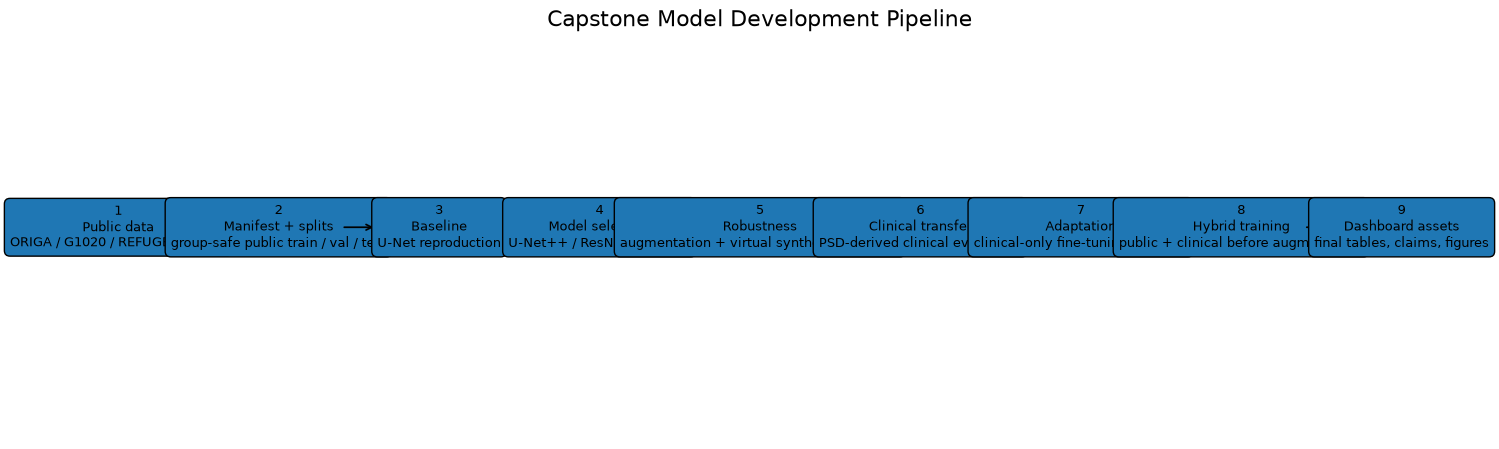

In [15]:
# 14.15 — Figure 1: project pipeline storyboard

pipeline_steps = [
    ("Public data", "ORIGA / G1020 / REFUGE / PAPILA"),
    ("Manifest + splits", "group-safe public train / val / test"),
    ("Baseline", "U-Net reproduction"),
    ("Model selection", "U-Net++ / ResNet18 finalist"),
    ("Robustness", "augmentation + virtual synthetic add-back"),
    ("Clinical transfer", "PSD-derived clinical evaluation"),
    ("Adaptation", "clinical-only fine-tuning fractions"),
    ("Hybrid training", "public + clinical before augmentation"),
    ("Dashboard assets", "final tables, claims, figures"),
]

fig, ax = plt.subplots(figsize=(18, 5))
ax.axis("off")

x_positions = np.linspace(0.04, 0.96, len(pipeline_steps))
y = 0.55

for idx, ((title, subtitle), x) in enumerate(zip(pipeline_steps, x_positions)):
    ax.text(
        x,
        y,
        f"{idx + 1}\n{title}\n{subtitle}",
        ha="center",
        va="center",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.45", "linewidth": 1},
        transform=ax.transAxes,
    )

    if idx < len(pipeline_steps) - 1:
        ax.annotate(
            "",
            xy=(x_positions[idx + 1] - 0.045, y),
            xytext=(x + 0.045, y),
            xycoords=ax.transAxes,
            arrowprops={"arrowstyle": "->", "linewidth": 1.25},
        )

ax.set_title("Capstone Model Development Pipeline", fontsize=16, pad=20)

save_current_figure(
    "pipeline_storyboard",
    "Capstone Model Development Pipeline",
    "Storyboard-style overview of the full public-data, clinical-transfer, adaptation, hybrid-training, and dashboard-output pipeline.",
)
plt.show()

Saved figure: reports/final/figures/data_composition.png
Saved dashboard figure: docs/dashboard_assets/figures/data_composition.png


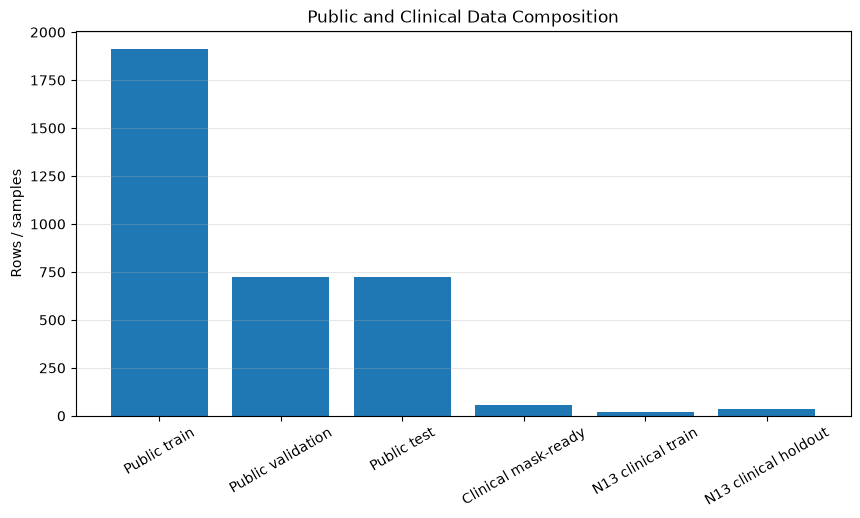

,label,rows
0,Public train,1911
1,Public validation,725
2,Public test,722
3,Clinical mask-ready,59
4,N13 clinical train,21
5,N13 clinical holdout,38


PosixPath('/sfs/gpfs/tardis<HOME>/Documents/MSDS/CAPSTONE/GitHub/Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy/reports/final/tables/data_composition_summary.csv')

In [16]:
# 14.16 — Figure 2: data composition and clinical split summary

n13_split = frame_or_empty("n13_split_summary")

data_counts = pd.DataFrame(
    [
        {"label": "Public train", "rows": 1911},
        {"label": "Public validation", "rows": 725},
        {"label": "Public test", "rows": 722},
        {"label": "Clinical mask-ready", "rows": clinical_mask_ready_count},
        {
            "label": "N13 clinical train",
            "rows": as_int(
                n13_split.loc[n13_split["split"].astype(str) == "hybrid_train_clinical_50pct_groups", "rows"].iloc[0]
                if not n13_split.empty and (n13_split["split"].astype(str) == "hybrid_train_clinical_50pct_groups").any()
                else 21
            ),
        },
        {
            "label": "N13 clinical holdout",
            "rows": as_int(
                n13_split.loc[n13_split["split"].astype(str) == "heldout_clinical_test_50pct_groups", "rows"].iloc[0]
                if not n13_split.empty and (n13_split["split"].astype(str) == "heldout_clinical_test_50pct_groups").any()
                else 38
            ),
        },
    ]
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(data_counts["label"], data_counts["rows"])
ax.set_ylabel("Rows / samples")
ax.set_title("Public and Clinical Data Composition")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

save_current_figure(
    "data_composition",
    "Public and Clinical Data Composition",
    "Counts for public split rows, mask-ready clinical samples, and Notebook 13 clinical train/holdout rows.",
)
plt.show()

display(data_counts)
save_table(data_counts, "data_composition_summary.csv")

Saved figure: reports/final/figures/public_performance_trajectory.png
Saved dashboard figure: docs/dashboard_assets/figures/public_performance_trajectory.png


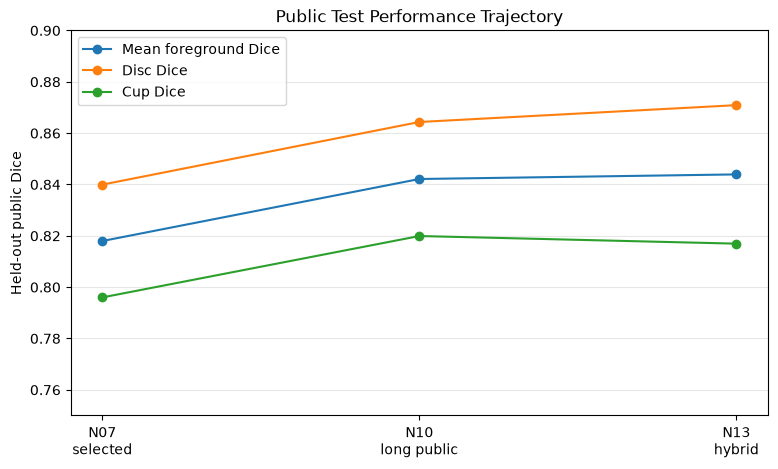

In [17]:
# 14.17 — Figure 3: public performance trajectory

public_plot = public_model_performance.copy()
public_plot["label"] = public_plot["notebook"].map(
    {
        "07": "N07\nselected",
        "10": "N10\nlong public",
        "13": "N13\nhybrid",
    }
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    public_plot["label"],
    public_plot["public_test_mean_foreground_dice"],
    marker="o",
    label="Mean foreground Dice",
)
ax.plot(
    public_plot["label"],
    public_plot["public_test_disc_dice"],
    marker="o",
    label="Disc Dice",
)
ax.plot(
    public_plot["label"],
    public_plot["public_test_cup_dice"],
    marker="o",
    label="Cup Dice",
)
ax.set_ylim(0.75, 0.90)
ax.set_ylabel("Held-out public Dice")
ax.set_title("Public Test Performance Trajectory")
ax.grid(axis="y", alpha=0.3)
ax.legend()

save_current_figure(
    "public_performance_trajectory",
    "Public Test Performance Trajectory",
    "Held-out public test Dice metrics for the selected public model, long public-training model, and hybrid model.",
)
plt.show()

Saved figure: reports/final/figures/public_to_clinical_gap.png
Saved dashboard figure: docs/dashboard_assets/figures/public_to_clinical_gap.png


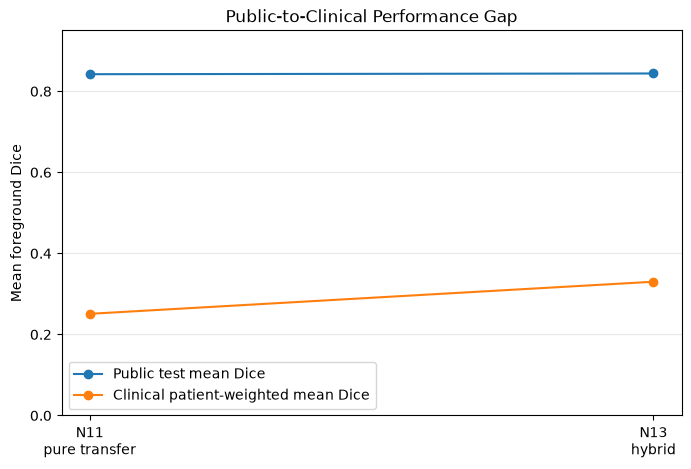

In [18]:
# 14.18 — Figure 4: public-to-clinical transfer gap

gap_rows = public_clinical_tradeoff.loc[
    public_clinical_tradeoff["clinical_patient_weighted_mean_foreground_dice"].notna()
].copy()
gap_rows["label"] = gap_rows["notebook"].map(
    {
        "11": "N11\npure transfer",
        "13": "N13\nhybrid",
    }
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    gap_rows["label"],
    gap_rows["public_test_mean_foreground_dice"],
    marker="o",
    label="Public test mean Dice",
)
ax.plot(
    gap_rows["label"],
    gap_rows["clinical_patient_weighted_mean_foreground_dice"],
    marker="o",
    label="Clinical patient-weighted mean Dice",
)
ax.set_ylim(0.0, 0.95)
ax.set_ylabel("Mean foreground Dice")
ax.set_title("Public-to-Clinical Performance Gap")
ax.grid(axis="y", alpha=0.3)
ax.legend()

save_current_figure(
    "public_to_clinical_gap",
    "Public-to-Clinical Performance Gap",
    "High public test performance contrasted with much lower clinical patient-weighted performance.",
)
plt.show()

Saved figure: reports/final/figures/clinical_strategy_dice.png
Saved dashboard figure: docs/dashboard_assets/figures/clinical_strategy_dice.png


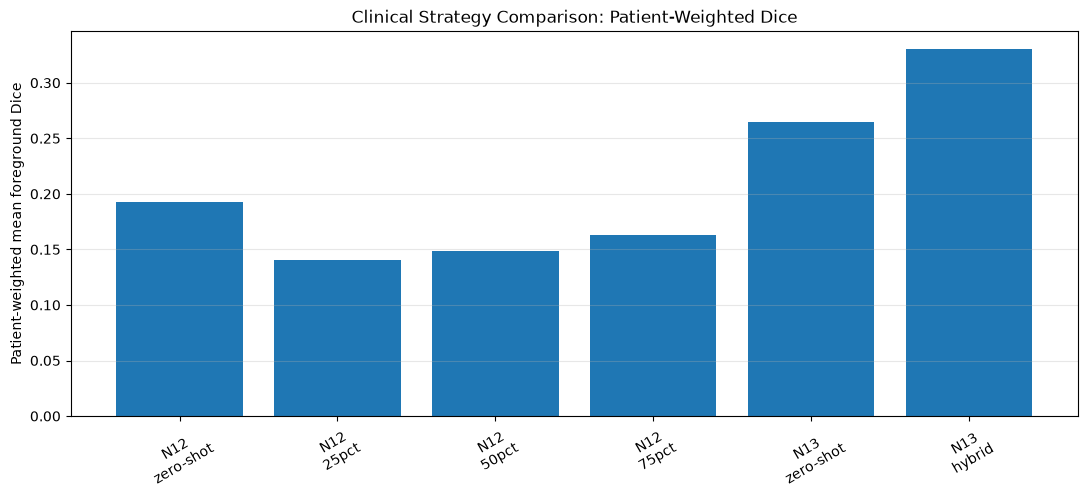

In [19]:
# 14.19 — Figure 5: clinical strategy comparison for patient-weighted Dice

strategy_plot = clinical_strategy_comparison.copy()
strategy_plot = strategy_plot.loc[
    strategy_plot["patient_weighted_mean_foreground_dice"].notna()
].copy()

strategy_plot["label"] = strategy_plot.apply(
    lambda row: f"N{row['notebook']}\n{str(row['condition']).replace('zero_shot_notebook_10_on_clinical_test', 'zero-shot').replace('zero_shot_notebook10_on_hybrid50_clinical_holdout', 'zero-shot').replace('clinical_adapt_', '').replace('hybrid_public_plus_50pct_clinical_preaugmentation', 'hybrid')}",
    axis=1,
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(strategy_plot["label"], strategy_plot["patient_weighted_mean_foreground_dice"])
ax.set_ylabel("Patient-weighted mean foreground Dice")
ax.set_title("Clinical Strategy Comparison: Patient-Weighted Dice")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

save_current_figure(
    "clinical_strategy_dice",
    "Clinical Strategy Comparison: Patient-Weighted Dice",
    "Patient-weighted held-out clinical Dice across Notebook 12 clinical-only adaptation and Notebook 13 hybrid training conditions.",
)
plt.show()

Saved figure: reports/final/figures/clinical_strategy_cdr.png
Saved dashboard figure: docs/dashboard_assets/figures/clinical_strategy_cdr.png


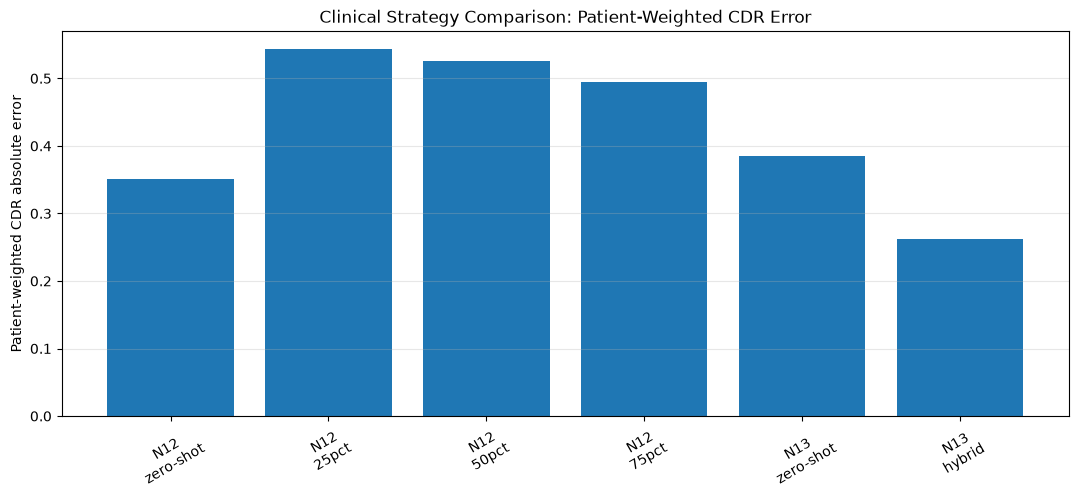

In [20]:
# 14.20 — Figure 6: clinical strategy comparison for CDR error

cdr_plot = clinical_strategy_comparison.copy()
cdr_plot = cdr_plot.loc[
    cdr_plot["patient_weighted_cdr_abs_error"].notna()
].copy()

cdr_plot["label"] = cdr_plot.apply(
    lambda row: f"N{row['notebook']}\n{str(row['condition']).replace('zero_shot_notebook_10_on_clinical_test', 'zero-shot').replace('zero_shot_notebook10_on_hybrid50_clinical_holdout', 'zero-shot').replace('clinical_adapt_', '').replace('hybrid_public_plus_50pct_clinical_preaugmentation', 'hybrid')}",
    axis=1,
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(cdr_plot["label"], cdr_plot["patient_weighted_cdr_abs_error"])
ax.set_ylabel("Patient-weighted CDR absolute error")
ax.set_title("Clinical Strategy Comparison: Patient-Weighted CDR Error")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

save_current_figure(
    "clinical_strategy_cdr",
    "Clinical Strategy Comparison: Patient-Weighted CDR Error",
    "Patient-weighted CDR absolute error across Notebook 12 clinical-only adaptation and Notebook 13 hybrid training conditions.",
)
plt.show()

Saved figure: reports/final/figures/evidence_matrix.png
Saved dashboard figure: docs/dashboard_assets/figures/evidence_matrix.png


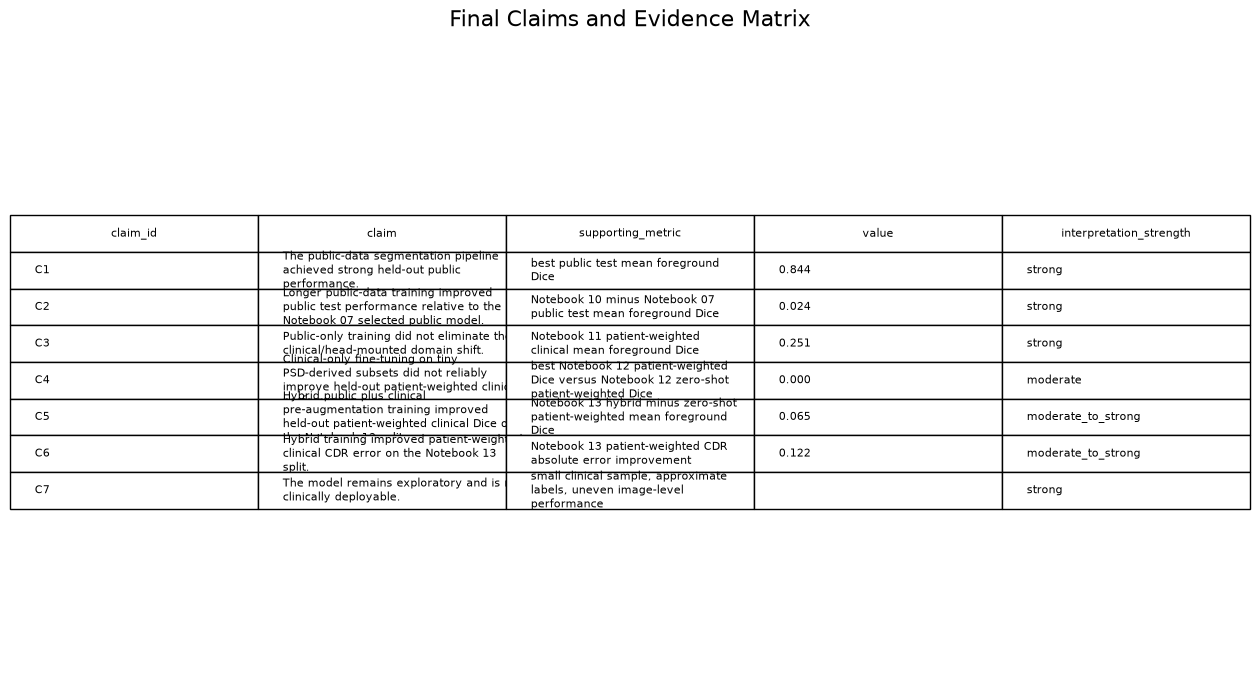

In [21]:
# 14.21 — Figure 7: evidence matrix table

evidence_display = claims[
    [
        "claim_id",
        "claim",
        "supporting_metric",
        "value",
        "interpretation_strength",
    ]
].copy()

evidence_display["claim"] = evidence_display["claim"].map(lambda text: short_label(text, width=42))
evidence_display["supporting_metric"] = evidence_display["supporting_metric"].map(lambda text: short_label(text, width=34))
evidence_display["value"] = evidence_display["value"].map(
    lambda value: "" if pd.isna(value) else f"{float(value):.3f}"
)

fig, ax = plt.subplots(figsize=(16, 8))
ax.axis("off")
table = ax.table(
    cellText=evidence_display.values,
    colLabels=evidence_display.columns,
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2.2)
ax.set_title("Final Claims and Evidence Matrix", fontsize=16, pad=20)

save_current_figure(
    "evidence_matrix",
    "Final Claims and Evidence Matrix",
    "Compact visual table linking final project claims to metrics, notebooks, and caveats.",
)
plt.show()

In [22]:
# 14.22 — Dashboard data dictionary and asset manifest

dashboard_files = [
    {
        "file": "model_development_registry.csv",
        "description": "Ordered model-development timeline and experiment registry.",
        "dashboard_usage": "timeline and storyboard navigation",
    },
    {
        "file": "public_model_performance_summary.csv",
        "description": "Public held-out test performance for the key final models.",
        "dashboard_usage": "public performance charts and KPI context",
    },
    {
        "file": "clinical_transfer_summary.csv",
        "description": "Pure clinical generalization comparison for public-only models.",
        "dashboard_usage": "clinical domain-shift section",
    },
    {
        "file": "clinical_strategy_comparison_summary.csv",
        "description": "Clinical-only adaptation and hybrid training comparison table.",
        "dashboard_usage": "clinical strategy comparison charts",
    },
    {
        "file": "public_clinical_tradeoff_summary.csv",
        "description": "Public versus clinical tradeoff table for key final model states.",
        "dashboard_usage": "public-to-clinical gap panel",
    },
    {
        "file": "dashboard_kpi_cards.json",
        "description": "Dashboard KPI card values and labels.",
        "dashboard_usage": "top-line dashboard cards",
    },
    {
        "file": "dashboard_story_sections.json",
        "description": "Dashboard storyboard sections and takeaways.",
        "dashboard_usage": "narrative dashboard text",
    },
    {
        "file": "final_claims_evidence_matrix.csv",
        "description": "Final claims, supporting evidence, caveats, and dashboard sections.",
        "dashboard_usage": "claims/evidence section",
    },
]

data_dictionary_rows = []
for item in dashboard_files:
    data_dictionary_rows.append(
        {
            "file": item["file"],
            "field": "*",
            "type": "csv_or_json",
            "description": item["description"],
            "source_notebook": "14",
            "dashboard_usage": item["dashboard_usage"],
            "public_safe": True,
        }
    )

data_dictionary = pd.DataFrame(data_dictionary_rows)
save_table(data_dictionary, "dashboard_data_dictionary.csv")

asset_manifest = pd.DataFrame(
    [
        {
            "asset_id": row["asset_id"],
            "asset_type": row["asset_type"],
            "path": row["docs_path"],
            "reports_path": row["reports_path"],
            "title": row["title"],
            "description": row["description"],
            "public_safe": True,
        }
        for row in figure_registry
    ]
)

asset_manifest = pd.concat(
    [
        asset_manifest,
        pd.DataFrame(
            [
                {
                    "asset_id": item["file"].replace(".", "_"),
                    "asset_type": "dashboard_data",
                    "path": f"docs/dashboard_data/{item['file']}",
                    "reports_path": f"reports/final/{item['file']}"
                    if item["file"].endswith(".json")
                    else f"reports/final/tables/{item['file']}",
                    "title": item["file"],
                    "description": item["description"],
                    "public_safe": True,
                }
                for item in dashboard_files
            ]
        ),
    ],
    ignore_index=True,
)

save_table(asset_manifest, "dashboard_assets_manifest.csv")

display(data_dictionary)
display(asset_manifest)

,file,field,type,description,source_notebook,dashboard_usage,public_safe
0,model_development_registry.csv,*,csv_or_json,Ordered model-development timeline and experim...,14,timeline and storyboard navigation,True
1,public_model_performance_summary.csv,*,csv_or_json,Public held-out test performance for the key f...,14,public performance charts and KPI context,True
2,clinical_transfer_summary.csv,*,csv_or_json,Pure clinical generalization comparison for pu...,14,clinical domain-shift section,True
3,clinical_strategy_comparison_summary.csv,*,csv_or_json,Clinical-only adaptation and hybrid training c...,14,clinical strategy comparison charts,True
4,public_clinical_tradeoff_summary.csv,*,csv_or_json,Public versus clinical tradeoff table for key ...,14,public-to-clinical gap panel,True
5,dashboard_kpi_cards.json,*,csv_or_json,Dashboard KPI card values and labels.,14,top-line dashboard cards,True
6,dashboard_story_sections.json,*,csv_or_json,Dashboard storyboard sections and takeaways.,14,narrative dashboard text,True
7,final_claims_evidence_matrix.csv,*,csv_or_json,"Final claims, supporting evidence, caveats, an...",14,claims/evidence section,True


,asset_id,asset_type,path,reports_path,title,description,public_safe
0,pipeline_storyboard,figure,docs/dashboard_assets/figures/pipeline_storybo...,reports/final/figures/pipeline_storyboard.png,Capstone Model Development Pipeline,Storyboard-style overview of the full public-d...,True
1,data_composition,figure,docs/dashboard_assets/figures/data_composition...,reports/final/figures/data_composition.png,Public and Clinical Data Composition,"Counts for public split rows, mask-ready clini...",True
2,public_performance_trajectory,figure,docs/dashboard_assets/figures/public_performan...,reports/final/figures/public_performance_traje...,Public Test Performance Trajectory,Held-out public test Dice metrics for the sele...,True
3,public_to_clinical_gap,figure,docs/dashboard_assets/figures/public_to_clinic...,reports/final/figures/public_to_clinical_gap.png,Public-to-Clinical Performance Gap,High public test performance contrasted with m...,True
4,clinical_strategy_dice,figure,docs/dashboard_assets/figures/clinical_strateg...,reports/final/figures/clinical_strategy_dice.png,Clinical Strategy Comparison: Patient-Weighted...,Patient-weighted held-out clinical Dice across...,True
5,clinical_strategy_cdr,figure,docs/dashboard_assets/figures/clinical_strateg...,reports/final/figures/clinical_strategy_cdr.png,Clinical Strategy Comparison: Patient-Weighted...,Patient-weighted CDR absolute error across Not...,True
6,evidence_matrix,figure,docs/dashboard_assets/figures/evidence_matrix.png,reports/final/figures/evidence_matrix.png,Final Claims and Evidence Matrix,Compact visual table linking final project cla...,True
7,model_development_registry_csv,dashboard_data,docs/dashboard_data/model_development_registry...,reports/final/tables/model_development_registr...,model_development_registry.csv,Ordered model-development timeline and experim...,True
8,public_model_performance_summary_csv,dashboard_data,docs/dashboard_data/public_model_performance_s...,reports/final/tables/public_model_performance_...,public_model_performance_summary.csv,Public held-out test performance for the key f...,True
9,clinical_transfer_summary_csv,dashboard_data,docs/dashboard_data/clinical_transfer_summary.csv,reports/final/tables/clinical_transfer_summary...,clinical_transfer_summary.csv,Pure clinical generalization comparison for pu...,True


In [23]:
# 14.23 — Mirror dashboard data into docs/

files_to_mirror = [
    FINAL_TABLES_DIR / "model_development_registry.csv",
    FINAL_TABLES_DIR / "public_model_performance_summary.csv",
    FINAL_TABLES_DIR / "clinical_transfer_summary.csv",
    FINAL_TABLES_DIR / "clinical_strategy_comparison_summary.csv",
    FINAL_TABLES_DIR / "public_clinical_tradeoff_summary.csv",
    FINAL_TABLES_DIR / "final_claims_evidence_matrix.csv",
    FINAL_TABLES_DIR / "dashboard_data_dictionary.csv",
    FINAL_TABLES_DIR / "dashboard_assets_manifest.csv",
    FINAL_DIR / "dashboard_kpi_cards.json",
    FINAL_DIR / "dashboard_story_sections.json",
    FINAL_DIR / "final_claims_evidence_matrix.json",
]

mirrored_rows = []

for source in files_to_mirror:
    if not source.exists():
        raise FileNotFoundError(source)

    destination = DOCS_DATA_DIR / source.name
    shutil.copyfile(source, destination)

    mirrored_rows.append(
        {
            "source": str(source.relative_to(PROJECT_ROOT)),
            "destination": str(destination.relative_to(PROJECT_ROOT)),
            "size_bytes": destination.stat().st_size,
        }
    )

mirrored = pd.DataFrame(mirrored_rows)
save_table(mirrored, "dashboard_mirrored_assets.csv")

display(mirrored)

,source,destination,size_bytes
0,reports/final/tables/model_development_registr...,docs/dashboard_data/model_development_registry...,3097
1,reports/final/tables/public_model_performance_...,docs/dashboard_data/public_model_performance_s...,849
2,reports/final/tables/clinical_transfer_summary...,docs/dashboard_data/clinical_transfer_summary.csv,665
3,reports/final/tables/clinical_strategy_compari...,docs/dashboard_data/clinical_strategy_comparis...,1778
4,reports/final/tables/public_clinical_tradeoff_...,docs/dashboard_data/public_clinical_tradeoff_s...,1021
5,reports/final/tables/final_claims_evidence_mat...,docs/dashboard_data/final_claims_evidence_matr...,2411
6,reports/final/tables/dashboard_data_dictionary...,docs/dashboard_data/dashboard_data_dictionary.csv,1223
7,reports/final/tables/dashboard_assets_manifest...,docs/dashboard_data/dashboard_assets_manifest.csv,4091
8,reports/final/dashboard_kpi_cards.json,docs/dashboard_data/dashboard_kpi_cards.json,1935
9,reports/final/dashboard_story_sections.json,docs/dashboard_data/dashboard_story_sections.json,4643


In [24]:
# 14.24 — Create GitHub Pages static dashboard starter

index_html = """<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Glaucoma Segmentation Capstone Dashboard</title>
  <link rel="stylesheet" href="styles.css">
</head>
<body>
  <header class="hero">
    <p class="eyebrow">UVA MSDS Capstone</p>
    <h1>AI-Enhanced Ophthalmoscopy: Segmentation Model Development Storyboard</h1>
    <p class="lede">
      A public-safe dashboard summarizing the model-development pipeline, public segmentation performance,
      clinical transfer experiments, and final evidence-backed project conclusions.
    </p>
  </header>

  <main>
    <section class="panel">
      <h2>Key Metrics</h2>
      <div id="kpi-grid" class="kpi-grid"></div>
    </section>

    <section class="panel">
      <h2>Project Storyboard</h2>
      <div id="story-sections" class="story-sections"></div>
    </section>

    <section class="panel">
      <h2>Final Figures</h2>
      <div class="figure-grid">
        <figure><img src="dashboard_assets/figures/pipeline_storyboard.png" alt="Pipeline storyboard"><figcaption>Pipeline storyboard</figcaption></figure>
        <figure><img src="dashboard_assets/figures/public_performance_trajectory.png" alt="Public performance trajectory"><figcaption>Public performance trajectory</figcaption></figure>
        <figure><img src="dashboard_assets/figures/public_to_clinical_gap.png" alt="Public-to-clinical gap"><figcaption>Public-to-clinical gap</figcaption></figure>
        <figure><img src="dashboard_assets/figures/clinical_strategy_dice.png" alt="Clinical strategy Dice comparison"><figcaption>Clinical strategy Dice comparison</figcaption></figure>
        <figure><img src="dashboard_assets/figures/clinical_strategy_cdr.png" alt="Clinical strategy CDR error comparison"><figcaption>Clinical strategy CDR error comparison</figcaption></figure>
        <figure><img src="dashboard_assets/figures/evidence_matrix.png" alt="Evidence matrix"><figcaption>Evidence matrix</figcaption></figure>
      </div>
    </section>

    <section class="panel">
      <h2>Claims and Evidence</h2>
      <div id="claims-table"></div>
    </section>
  </main>

  <footer>
    <p>Generated from public-safe aggregate artifacts in <code>reports/final/</code> and <code>docs/dashboard_data/</code>.</p>
  </footer>

  <script src="app.js"></script>
</body>
</html>
"""

styles_css = """body {
  margin: 0;
  font-family: system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
  background: #f7f7f8;
  color: #1f2933;
}

.hero {
  padding: 48px 8vw;
  background: #111827;
  color: white;
}

.eyebrow {
  text-transform: uppercase;
  letter-spacing: 0.12em;
  font-size: 0.8rem;
  opacity: 0.8;
}

h1 {
  max-width: 980px;
  font-size: clamp(2rem, 4vw, 4rem);
  line-height: 1.05;
  margin: 0.2em 0;
}

.lede {
  max-width: 900px;
  font-size: 1.15rem;
  line-height: 1.6;
  opacity: 0.9;
}

main {
  padding: 32px 8vw 64px;
}

.panel {
  background: white;
  border: 1px solid #e5e7eb;
  border-radius: 18px;
  padding: 28px;
  margin: 0 0 28px;
  box-shadow: 0 8px 30px rgba(15, 23, 42, 0.06);
}

.kpi-grid {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(220px, 1fr));
  gap: 16px;
}

.kpi-card {
  border: 1px solid #e5e7eb;
  border-radius: 14px;
  padding: 18px;
  background: #fafafa;
}

.kpi-value {
  font-size: 2rem;
  font-weight: 800;
  margin: 0.2rem 0;
}

.kpi-label {
  font-weight: 700;
}

.kpi-context {
  color: #4b5563;
  line-height: 1.45;
}

.story-card {
  border-left: 4px solid #111827;
  padding: 0 0 0 16px;
  margin: 22px 0;
}

.story-card h3 {
  margin-bottom: 0.25rem;
}

.story-card p {
  line-height: 1.55;
}

.figure-grid {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(320px, 1fr));
  gap: 20px;
}

figure {
  margin: 0;
}

figure img {
  width: 100%;
  border: 1px solid #e5e7eb;
  border-radius: 12px;
  background: white;
}

figcaption {
  color: #4b5563;
  margin-top: 8px;
  font-size: 0.95rem;
}

table {
  border-collapse: collapse;
  width: 100%;
  font-size: 0.92rem;
}

th, td {
  border-bottom: 1px solid #e5e7eb;
  padding: 10px;
  text-align: left;
  vertical-align: top;
}

th {
  background: #f3f4f6;
}

footer {
  padding: 24px 8vw;
  color: #4b5563;
}
"""

app_js = """async function loadJson(path) {
  const response = await fetch(path);
  if (!response.ok) throw new Error(`Could not load ${path}`);
  return await response.json();
}

async function loadCsv(path) {
  const text = await (await fetch(path)).text();
  const lines = text.trim().split(/\r?\n/);
  const headers = lines[0].split(",");
  return lines.slice(1).map(line => {
    const values = line.match(/(".*?"|[^",]+)(?=\s*,|\s*$)/g) || [];
    const row = {};
    headers.forEach((header, index) => {
      row[header] = (values[index] || "").replace(/^"|"$/g, "");
    });
    return row;
  });
}

function renderKpis(kpis) {
  const grid = document.getElementById("kpi-grid");
  grid.innerHTML = "";
  kpis.sort((a, b) => Number(a.priority) - Number(b.priority)).forEach(kpi => {
    const card = document.createElement("article");
    card.className = "kpi-card";
    card.innerHTML = `
      <div class="kpi-label">${kpi.label}</div>
      <div class="kpi-value">${kpi.display_value}</div>
      <div class="kpi-context">${kpi.context}</div>
      <small>${kpi.source}</small>
    `;
    grid.appendChild(card);
  });
}

function renderStory(sections) {
  const container = document.getElementById("story-sections");
  container.innerHTML = "";
  sections.sort((a, b) => Number(a.dashboard_priority) - Number(b.dashboard_priority)).forEach(section => {
    const card = document.createElement("article");
    card.className = "story-card";
    card.innerHTML = `
      <h3>${section.title}</h3>
      <p><strong>${section.one_sentence_takeaway}</strong></p>
      <p>${section.long_takeaway}</p>
      <small>Source notebooks: ${section.source_notebooks.join(", ")}</small>
    `;
    container.appendChild(card);
  });
}

function renderClaims(claims) {
  const container = document.getElementById("claims-table");
  const rows = claims.map(row => `
    <tr>
      <td>${row.claim_id}</td>
      <td>${row.claim}</td>
      <td>${row.supporting_metric}</td>
      <td>${row.value || ""}</td>
      <td>${row.interpretation_strength}</td>
      <td>${row.caveat}</td>
    </tr>
  `).join("");

  container.innerHTML = `
    <table>
      <thead>
        <tr>
          <th>ID</th>
          <th>Claim</th>
          <th>Evidence</th>
          <th>Value</th>
          <th>Strength</th>
          <th>Caveat</th>
        </tr>
      </thead>
      <tbody>${rows}</tbody>
    </table>
  `;
}

async function main() {
  const [kpis, story, claims] = await Promise.all([
    loadJson("dashboard_data/dashboard_kpi_cards.json"),
    loadJson("dashboard_data/dashboard_story_sections.json"),
    loadJson("dashboard_data/final_claims_evidence_matrix.json"),
  ]);

  renderKpis(kpis);
  renderStory(story);
  renderClaims(claims);
}

main().catch(error => {
  document.body.insertAdjacentHTML("beforeend", `<pre>${error}</pre>`);
});
"""

(DOCS_DIR / "index.html").write_text(index_html, encoding="utf-8")
(DOCS_DIR / "styles.css").write_text(styles_css, encoding="utf-8")
(DOCS_DIR / "app.js").write_text(app_js, encoding="utf-8")
(DOCS_DIR / ".nojekyll").write_text("", encoding="utf-8")

dashboard_files_created = pd.DataFrame(
    [
        {"path": str((DOCS_DIR / "index.html").relative_to(PROJECT_ROOT)), "role": "GitHub Pages starter dashboard"},
        {"path": str((DOCS_DIR / "styles.css").relative_to(PROJECT_ROOT)), "role": "dashboard styling"},
        {"path": str((DOCS_DIR / "app.js").relative_to(PROJECT_ROOT)), "role": "dashboard data loading and rendering"},
        {"path": str((DOCS_DIR / ".nojekyll").relative_to(PROJECT_ROOT)), "role": "GitHub Pages static-file compatibility marker"},
    ]
)

save_table(dashboard_files_created, "github_pages_starter_files.csv")
display(dashboard_files_created)

,path,role
0,docs/index.html,GitHub Pages starter dashboard
1,docs/styles.css,dashboard styling
2,docs/app.js,dashboard data loading and rendering
3,docs/.nojekyll,GitHub Pages static-file compatibility marker


In [25]:
# 14.25 — Final project interpretation

final_interpretation = f"""
# Final Project Interpretation

The final project arc supports a clear conclusion: the public-data segmentation pipeline became strong on held-out public data, but public performance alone did not solve clinical/head-mounted transfer.

The selected public-data model from Notebook 07 achieved a public test mean foreground Dice of {n07_public_mean:.6f}. Longer public-data training with the selected combined augmentation recipe improved this to {n10_public_mean:.6f} in Notebook 10. The hybrid public-clinical model in Notebook 13 preserved strong public performance with a public test mean foreground Dice of {n13_public_mean:.6f}.

Clinical transfer remained the central difficulty. In pure clinical generalization, the long public-trained model reached a patient-weighted clinical mean foreground Dice of {n11_patient_mean:.6f}, far below its public test performance. Notebook 12 showed that clinical-only fine-tuning on very small PSD-derived subsets was unstable and did not reliably improve held-out patient-weighted performance.

Notebook 13 produced the strongest clinical-domain result. Adding 50% of clinical patient/encounter groups into the public training pool before virtual synthetic expansion improved held-out patient-weighted clinical mean foreground Dice by {n13_patient_delta:.6f} relative to the internal zero-shot Notebook 10 baseline and improved patient-weighted CDR absolute error by {n13_cdr_improvement:.6f}. This suggests that hybrid training can use clinical-domain signal more effectively than tiny clinical-only fine-tuning.

The result remains exploratory. The clinical subset is small, the masks are approximate PSD-derived labels, and individual-image performance remains uneven. The model is not clinically deployable. The next research step is larger patient-group clinical annotation, more robust domain adaptation, and prospective validation with clinical review.
""".strip()

interpretation_path = FINAL_DIR / "final_project_interpretation.md"
interpretation_path.write_text(final_interpretation, encoding="utf-8")

docs_interpretation_path = DOCS_DATA_DIR / "final_project_interpretation.md"
docs_interpretation_path.write_text(final_interpretation, encoding="utf-8")

print(final_interpretation)
print()
print(f"Saved: {interpretation_path.relative_to(PROJECT_ROOT)}")
print(f"Saved: {docs_interpretation_path.relative_to(PROJECT_ROOT)}")

# Final Project Interpretation

The final project arc supports a clear conclusion: the public-data segmentation pipeline became strong on held-out public data, but public performance alone did not solve clinical/head-mounted transfer.

The selected public-data model from Notebook 07 achieved a public test mean foreground Dice of 0.817976. Longer public-data training with the selected combined augmentation recipe improved this to 0.842136 in Notebook 10. The hybrid public-clinical model in Notebook 13 preserved strong public performance with a public test mean foreground Dice of 0.843930.

Clinical transfer remained the central difficulty. In pure clinical generalization, the long public-trained model reached a patient-weighted clinical mean foreground Dice of 0.250879, far below its public test performance. Notebook 12 showed that clinical-only fine-tuning on very small PSD-derived subsets was unstable and did not reliably improve held-out patient-weighted performance.

Notebook 13 pro

In [26]:
# 14.26 — Notebook 14 handoff summary

handoff_summary = pd.DataFrame(
    [
        {
            "notebook": "14_final_comparative_analysis_and_dashboard_assets",
            "created_utc": RUN_TIMESTAMP_UTC,
            "final_tables_dir": str(FINAL_TABLES_DIR.relative_to(PROJECT_ROOT)),
            "final_figures_dir": str(FINAL_FIGURES_DIR.relative_to(PROJECT_ROOT)),
            "docs_dir": str(DOCS_DIR.relative_to(PROJECT_ROOT)),
            "dashboard_data_dir": str(DOCS_DATA_DIR.relative_to(PROJECT_ROOT)),
            "dashboard_assets_dir": str(DOCS_ASSETS_DIR.relative_to(PROJECT_ROOT)),
            "kpi_count": int(len(dashboard_kpis)),
            "story_section_count": int(len(story_sections)),
            "claim_count": int(len(claims)),
            "figure_count": int(len(figure_registry)),
            "github_pages_starter_created": True,
            "next_step": "Audit, commit Notebook 14 outputs, then enable GitHub Pages from the docs directory.",
        }
    ]
)

save_table(handoff_summary, "notebook_14_handoff_summary.csv")

display(handoff_summary)

print("Notebook 14 complete.")

,notebook,created_utc,final_tables_dir,final_figures_dir,docs_dir,dashboard_data_dir,dashboard_assets_dir,kpi_count,story_section_count,claim_count,figure_count,github_pages_starter_created,next_step
0,14_final_comparative_analysis_and_dashboard_as...,2026-07-12T23:59:08+00:00,reports/final/tables,reports/final/figures,docs,docs/dashboard_data,docs/dashboard_assets,6,7,7,7,True,"Audit, commit Notebook 14 outputs, then enable..."


Notebook 14 complete.
